# Imports

In [1]:
import os
import pickle
from io import BytesIO

import numpy as np
import jax
import jax.numpy as jnp
import optax

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib import colors, cm

import time
import functools
from functools import partial
from collections import defaultdict
from typing import Any, Callable, NamedTuple, Optional


## Utility Functions - Plotting

In [2]:
### Plotting Labels and Colors ###

LABEL_MAP = {
    "ImpDiff_Adam": "ImpDiff-Adam",
    "ImpDiff_SGD": "ImpDiff-SGD",
    "SOSMC-ULA_Adam": "SOSMC-ULA-Adam",
    "SOSMC-ULA_SGD": "SOSMC-ULA-SGD",
    "SOSMC-MALA_SGD": "SOSMC-MALA-SGD",
    "SOSMC-MALA_Adam": "SOSMC-MALA-Adam",
    "SOSMC-RWM_SGD": "SOSMC-RWM-SGD",
    "SOSMC-RWM_Adam": "SOSMC-RWM-Adam",
    "SOSMC-HMC_SGD": "SOSMC-HMC-SGD",
    "SOSMC-HMC_Adam": "SOSMC-HMC-Adam",
    "SOUL_Adam": "SOUL-Adam",
    "SOUL_SGD": "SOUL-SGD",
}

FAMILY_COLOR = {
    "ImpDiff": "#003f5c",
    "SOSMC-ULA": "#bc5090",
    "SOSMC-MALA": "#7a5195",
    "SOSMC-RWM": "#0AF102",
    "SOSMC-HMC": "#000000",
    "SOUL": "#ffa600",
}

COLOR_MAP = FAMILY_COLOR

def get_color(name):
    for key, color in COLOR_MAP.items():
        if key in name:
            return color
    return "black"


def family_of(loop_type: str) -> str:
    if loop_type.startswith("ImpDiff"):
        return "ImpDiff"
    if loop_type.startswith("SOSMC-ULA"):
        return "SOSMC-ULA"
    if loop_type.startswith("SOSMC-MALA"):
        return "SOSMC-MALA"
    if loop_type.startswith("SOSMC-RWM"):
        return "SOSMC-RWM"
    if loop_type.startswith("SOSMC-HMC"):
        return "SOSMC-HMC"
    if loop_type.startswith("SOUL"):
        return "SOUL"
    return "Other"


def method_color(loop_type: str) -> str:
    return FAMILY_COLOR.get(family_of(loop_type), "black")


def method_linestyle(loop_type: str) -> str:
    if "_Adam" in loop_type:
        return "-"
    if "_SGD" in loop_type:
        return "--"
    return ":"


### Collation of results across runs ###
 
def common_time_grid_for_runs(runs, num=250, strategy="min_end"):
    """
    Creates a common time grid over multiple runs.
    strategy:
      - "min_end": stop at the shortest completed run
      - "max_end": stop at the longest completed run
    """
    ends = [float(r["time"][-1]) for r in runs if "time" in r and len(r["time"]) > 0]
    if not ends:
        raise ValueError("No time arrays found in runs.")

    t_end = min(ends) if strategy == "min_end" else max(ends)
    return np.linspace(0.0, t_end, num=num)


def carry_forward_runs_to_grid(runs, metric_key, t_grid, require_started=True):
    """
    Piecewise-constant carry-forward interpolation on time grid.
    """
    Y = []
    for r in runs:
        if "time" not in r:
            raise ValueError("Run missing 'time' for time-grid interpolation.")

        t = np.asarray(r["time"], float)
        y = np.asarray(r[metric_key], float)

        vals = np.full(len(t_grid), np.nan)
        if len(t) == 0:
            Y.append(vals)
            continue

        idx = np.searchsorted(t, t_grid, side="right") - 1

        for j, k in enumerate(idx):
            if k >= 0:
                vals[j] = y[k]
            elif not require_started:
                vals[j] = y[0]

        Y.append(vals)

    return np.asarray(Y)


def mean_and_ci(Y, ci=0.95):
    """
    Returns mean, lower, upper, count over runs, ignoring NaNs.
    """
    mean = np.nanmean(Y, axis=0)
    n = np.sum(~np.isnan(Y), axis=0)

    std = np.nanstd(Y, axis=0, ddof=1)
    se = std / np.sqrt(np.maximum(n, 1))

    z = 1.96 if abs(ci - 0.95) < 1e-12 else 1.96
    lo = mean - z * se
    hi = mean + z * se
    return mean, lo, hi, n


### Plotting collated results across runs ###

def plot_reward_and_nll_fixed_beta(
    sweep_results,
    beta_kl,
    methods,
    time_grid_num=250,
    time_grid_strategy="min_end",
    include_accept=False,
    pdf_path=None,
):
    beta_kl = float(beta_kl)
    runs_by_method = {m: sweep_results[(m, beta_kl)] for m in methods if (m, beta_kl) in sweep_results}
    methods_present = [m for m in methods if m in runs_by_method]

    all_runs = [r for runs in runs_by_method.values() for r in runs]
    t_grid = common_time_grid_for_runs(all_runs, num=time_grid_num, strategy=time_grid_strategy)

    ncols = 3 if include_accept else 2
    fig, axes = plt.subplots(1, ncols, figsize=(3.8 * ncols, 3.6), sharex=True)

    ax_reward = axes[0]
    ax_nll = axes[1]
    ax_accept = axes[2] if include_accept else None

    for m in methods_present:
        runs = runs_by_method[m]

        # Reward
        Y_reward = carry_forward_runs_to_grid(runs, "reward", t_grid, require_started=True)
        mean_r, lo_r, hi_r, n_r = mean_and_ci(Y_reward)
        ax_reward.plot(t_grid, mean_r, lw=2.3, color=method_color(m), linestyle=method_linestyle(m), label=LABEL_MAP.get(m, m))
        ax_reward.fill_between(t_grid, lo_r, hi_r, alpha=0.12, color=method_color(m))

        # Nll Proxy
        Y_nll = carry_forward_runs_to_grid(runs, "nll", t_grid, require_started=True)
        mean_n, lo_n, hi_n, n_n = mean_and_ci(Y_nll)
        ax_nll.plot(t_grid, mean_n, lw=2.3, color=method_color(m), linestyle=method_linestyle(m), label=LABEL_MAP.get(m, m))
        ax_nll.fill_between(t_grid, lo_n, hi_n, alpha=0.12, color=method_color(m))

        # Accept Rate
        if include_accept and any("accept_rate" in r for r in runs):
            runs_accept = [r for r in runs if "accept_rate" in r]
            if len(runs_accept) > 0:
                Y_acc = carry_forward_runs_to_grid(runs_accept, "accept_rate", t_grid, require_started=True)
                mean_a, lo_a, hi_a, n_a = mean_and_ci(Y_acc)
                ax_accept.plot(t_grid, mean_a, lw=2.3, color=method_color(m), linestyle=method_linestyle(m), label=LABEL_MAP.get(m, m))
                ax_accept.fill_between(t_grid, lo_a, hi_a, alpha=0.12, color=method_color(m))

    ax_reward.set_xlabel("Time (s)")
    ax_reward.set_ylabel("Reward")
    ax_reward.grid(True, alpha=0.2)

    ax_nll.set_xlabel("Time (s)")
    ax_nll.set_ylabel("NLL Proxy")
    ax_nll.grid(True, alpha=0.2)

    if include_accept:
        ax_accept.set_xlabel("Time (s)")
        ax_accept.set_ylabel("Acceptance Rate")
        ax_accept.grid(True, alpha=0.2)

    handles = [
        Line2D([0], [0], color=method_color(m), linestyle=method_linestyle(m), lw=2.6, label=LABEL_MAP.get(m, m))
        for m in methods_present
    ]
    fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, 1.05), ncol=min(3, len(methods_present)), frameon=False)

    plt.tight_layout(rect=(0, 0, 1, 0.93))
    plt.show()

    if pdf_path is not None:
        fig.savefig(pdf_path, format="pdf", bbox_inches="tight")

## Utility Functions - Problem Setup

In [3]:
### Energy and Sampling Logic ###

def init_from_pref(
    rng: jnp.ndarray,
    n: int,
    dim_x: int,
    reference_sampler_func: Callable,
):
    """
    Draws n samples from `p_ref` using the passed API sampler:
    """
    placeholder = jnp.zeros((n, dim_x))
    return reference_sampler_func(rng, placeholder)
    # return jax.random.normal(rng, shape=(n, dim_x))


def gmm_energy(
    x: jnp.ndarray,
    theta: jnp.ndarray,
    means: jnp.ndarray,
    sig_sq: float,
):
    """
    Generalised version of `hex_mixture` from: https://github.com/google-deepmind/implicit_diffusion/blob/main/energy.py.
    """
    v = jax.nn.softmax(theta)
    sq_distances = jnp.sum((x - means) ** 2, axis=1)
    exponentials = jnp.exp(-sq_distances / (2*sig_sq))
    weighted_sum = jnp.sum(v * exponentials)
    return -jnp.log(weighted_sum + 1e-9)


def gmm_sampler(
    rng: jnp.ndarray,
    x_ref: jnp.ndarray,
    means: jnp.ndarray,
    sampling_theta: jnp.ndarray,
    sig_sq: float,
):
    """
    Generalised version of `hex_random` from: https://github.com/google-deepmind/implicit_diffusion/blob/main/energy.py.
    """
    probas = jax.nn.softmax(sampling_theta)
    bs = x_ref.shape[0]
    num_components = means.shape[0]
    rngs = jax.random.split(rng, 2)

    idxs = jax.random.choice(rngs[0], num_components, shape=(bs,), p=probas)
    std_dev = jnp.sqrt(sig_sq)
    return means[idxs] + std_dev * jax.random.normal(rngs[1], shape=means[idxs].shape)


### Rewards ###

def reward_hard(x: jnp.ndarray, center_reward: jnp.ndarray):
    tau = 20
    alpha = 2.5
    return (
        (x[0] >= 0).astype(float)
        * jnp.exp(
            -((x[0] - center_reward[0]) ** 2) / tau
            - (x[1] - center_reward[1]) ** 2 / tau
        )
        / alpha
    )


def reward_smooth(x: jnp.ndarray, center_reward: jnp.ndarray):
    tau = 20
    lamb_reg = 0.5
    alpha = 0.7
    return (
        jax.nn.sigmoid(x[0] / lamb_reg)
        * jnp.exp(
            -((x[0] - center_reward[0]) ** 2) / tau
            - (x[1] - center_reward[1]) ** 2 / tau
        )
        / alpha
    )


def reward_multimodal(x: jnp.ndarray, centers: jnp.ndarray):
    tau = 15
    rewards = jnp.array([jnp.exp(-jnp.sum((x - c) ** 2) / tau) for c in centers])
    return jnp.max(rewards) / 1.5

## Utility Functions - Algorithms

In [4]:
def build_optimiser(
    optimiser_name: str = "sgd",
    optimiser_kwargs: dict = None,
    default_learning_rate: float = None,
):
    """
    Builds an `optax` optimiser, based on passed `optimiser_name` and `optimiser_kwargs`.
    """
    OPTIMISER_MAP = {
        "sgd": optax.sgd,
        "adam": optax.adam,
        "adamw": optax.adamw,
        "rmsprop": optax.rmsprop,
    }

    if optimiser_kwargs is None:
        optimiser_kwargs = {}

    name = optimiser_name.lower().strip()
    factory = OPTIMISER_MAP.get(name)
    if factory is None:
        raise ValueError(
            f"Unknown optimiser_name={optimiser_name}. "
            f"The following are currently supported: {sorted(OPTIMISER_MAP.keys())}"
        )

    kw = dict(optimiser_kwargs)
    for alias in ("lr", "eta"):
        if alias in kw and "learning_rate" not in kw:
            kw["learning_rate"] = kw.pop(alias)

    if "learning_rate" not in kw:
        if default_learning_rate is None:
            raise ValueError("No learning rate provided!")
        kw["learning_rate"] = default_learning_rate

    return factory(**kw)


### Generic Updates ###

def update_x(rng, x, theta, gamma, grad_v_x):
    """
    As found at: https://github.com/google-deepmind/implicit_diffusion/blob/main/updates.py
    """
    z = jax.random.normal(rng, x.shape)
    x = x - gamma * grad_v_x(x, theta) + jnp.sqrt(2 * gamma) * z
    return x


def update_ref_wrapper(rng, x_ref, sampler_fn: Callable):
    return sampler_fn(rng, x_ref)

## Algorithms - ImpDiff

In [5]:
class StandardLoopState(NamedTuple):
    rng: jnp.ndarray
    x: jnp.ndarray
    x_ref: jnp.ndarray
    theta: jnp.ndarray
    opt_state: Any
    t: int


class StandardLoopOutputs(NamedTuple):
    reward: float
    kl_norm: float
    nll: float
    theta: jnp.ndarray
    x: jnp.ndarray


@functools.partial(jax.jit, static_argnames=("batch_reward_fn", "grad_v_theta_fn"))
def _compute_standard_grad(
    x: jnp.ndarray,
    theta: jnp.ndarray,
    x_ref: jnp.ndarray,
    batch_reward_fn: Callable,
    grad_v_theta_fn: Callable,
    lamb_kl: float,
):
    r = batch_reward_fn(x)
    g = grad_v_theta_fn(x, theta)

    B = x.shape[0]
    mean_r = jnp.mean(r)
    mean_g = jnp.mean(g, axis=0)

    grad_reward = -(r @ g) / B + mean_r * mean_g
    mean_ref = jnp.mean(grad_v_theta_fn(x_ref, theta), axis=0)
    grad_kl = mean_ref - mean_g
    total_ascent = grad_reward - lamb_kl * grad_kl

    return -total_ascent, jnp.linalg.norm(grad_kl)


def imp_diff(
    rng_seed: int,
    gamma: float,
    lamb_kl: float,
    batch_size: int,
    batch_size_ref: int,
    dim_x: int,
    run_mode: str,
    max_steps: int,
    max_time_seconds: float,
    print_option: bool,
    print_every: int,
    theta_init: Any,
    energy_func: Callable[[Any, Any], Any],
    reward_func: Callable[[Any, Any], Any],
    reference_sampler_func: Callable[[Any, Any], Any],
    optimiser_name: str = "sgd",
    optimiser_kwargs: dict = {"learning_rate": 0.1},
    utilise_warmup_step: bool = False,
) -> Any:
    """
    ImpDiff loop:
      - X updated via ULA with fixed gamma.
      - X_ref refreshed from reference sampler.
    """
    grad_v_x = jax.vmap(jax.grad(energy_func, argnums=0), in_axes=(0, None))
    grad_v_theta = jax.vmap(jax.grad(energy_func, argnums=1), in_axes=(0, None))

    batch_reward = jax.jit(jax.vmap(reward_func))
    batch_energy = jax.jit(jax.vmap(lambda x, th: energy_func(x, th), in_axes=(0, None)))

    update_x_fn = jax.jit(functools.partial(update_x, gamma=gamma, grad_v_x=grad_v_x))
    update_ref_fn = jax.jit(functools.partial(update_ref_wrapper, sampler_fn=reference_sampler_func))

    optimizer = build_optimiser(optimiser_name=optimiser_name, optimiser_kwargs=optimiser_kwargs)

    compute_grad_fn = functools.partial(
        _compute_standard_grad,
        batch_reward_fn=batch_reward,
        grad_v_theta_fn=grad_v_theta,
        lamb_kl=lamb_kl,
    )

    @jax.jit
    def standard_step(state: StandardLoopState, _):
        rng, x, x_ref, theta, opt_state, t = state

        rng, x_key, ref_key = jax.random.split(rng, 3)
        x_new = update_x_fn(x_key, x, theta)
        x_ref_new = update_ref_fn(ref_key, x_ref)

        grad_minimize, kl_norm = compute_grad_fn(x_new, theta, x_ref_new)
        updates, opt_state_new = optimizer.update(grad_minimize, opt_state, theta)
        theta_new = optax.apply_updates(theta, updates)

        nll = -jnp.mean(batch_energy(x_new, theta_new))
        current_reward = jnp.mean(batch_reward(x_new))

        next_state = StandardLoopState(
            rng=rng, x=x_new, x_ref=x_ref_new, theta=theta_new, opt_state=opt_state_new, t=t + 1
        )

        outputs = StandardLoopOutputs(
            reward=current_reward,
            kl_norm=kl_norm,
            nll=nll,
            theta=theta,
            x=x_new,
        )
        return next_state, outputs

    rng = jax.random.PRNGKey(rng_seed)
    rng, x_key, ref_key = jax.random.split(rng, 3)

    x_init = init_from_pref(x_key, batch_size, dim_x, reference_sampler_func)
    x_ref_init = init_from_pref(ref_key, batch_size_ref, dim_x, reference_sampler_func)

    opt_state_init = optimizer.init(theta_init)
    initial_state = StandardLoopState(
        rng=rng, x=x_init, x_ref=x_ref_init, theta=theta_init, opt_state=opt_state_init, t=0
    )

    if utilise_warmup_step:
        st_tmp, out_tmp = standard_step(initial_state, None)
        jax.block_until_ready(out_tmp.reward)

    if run_mode == "steps":
        print(f"Running ImpDiff (scan) for {max_steps} steps...")
        start_time = time.monotonic()

        final_state, history = jax.lax.scan(standard_step, initial_state, None, length=max_steps)
        jax.block_until_ready(history.reward)

        elapsed_time = time.monotonic() - start_time
        print(f"Scan completed in {elapsed_time:.2f} seconds.")

        return {
            "reward": np.array(history.reward),
            "kl": np.array(history.kl_norm),
            "nll": np.array(history.nll),
            "theta": np.array(history.theta),
            "x": np.array(history.x),
            "gamma": np.full(len(history.reward), gamma),
            "ess": np.full(len(history.reward), batch_size),
        }

    elif run_mode == "time":
        print(f"Running ImpDiff (JIT-step) for {max_time_seconds} seconds...")
        state = initial_state

        hist_reward, hist_kl, hist_nll, hist_theta, hist_x, hist_time = ([] for _ in range(6))

        start_time = time.monotonic()
        while True:
            state, outputs = standard_step(state, None)
            jax.block_until_ready(outputs.reward)

            elapsed_time = time.monotonic() - start_time
            if elapsed_time >= max_time_seconds:
                break

            hist_reward.append(outputs.reward)
            hist_kl.append(outputs.kl_norm)
            hist_nll.append(outputs.nll)
            hist_theta.append(outputs.theta)
            hist_x.append(outputs.x)
            hist_time.append(elapsed_time)

        return {
            "reward": np.array(jnp.array(hist_reward)),
            "kl": np.array(jnp.array(hist_kl)),
            "nll": np.array(jnp.array(hist_nll)),
            "theta": np.array(jnp.array(hist_theta)),
            "x": np.array(jnp.array(hist_x)),
            "gamma": np.full(len(hist_reward), gamma),
            "ess": np.full(len(hist_reward), batch_size),
            "time": np.array(hist_time),
        }

    else:
        raise ValueError(f"Unknown run_mode: {run_mode}. Use 'steps' or 'time'.")

## Algorithms - SOUL

In [6]:
class SoulLoopState(NamedTuple):
    rng: jnp.ndarray
    x_chain: jnp.ndarray
    x_ref: jnp.ndarray
    theta: jnp.ndarray
    opt_state: Any
    t: int


class SoulLoopOutputs(NamedTuple):
    reward: float
    kl_norm: float
    nll: float
    theta: jnp.ndarray
    x: jnp.ndarray
    gamma: float
    ess: float


@functools.partial(jax.jit, static_argnames=("batch_reward_fn", "grad_v_theta_fn"))
def _compute_soul_grad(
    x_samples: jnp.ndarray,
    theta: jnp.ndarray,
    x_ref: jnp.ndarray,
    batch_reward_fn: Callable,
    grad_v_theta_fn: Callable,
    lamb_kl: float,
):
    r = batch_reward_fn(x_samples)
    g = grad_v_theta_fn(x_samples, theta)

    mean_r = jnp.mean(r)
    mean_g = jnp.mean(g, axis=0)

    n_eff = x_samples.shape[0]
    grad_reward = -(r @ g) / n_eff + mean_r * mean_g
    mean_ref = jnp.mean(grad_v_theta_fn(x_ref, theta), axis=0)
    grad_kl = mean_ref - mean_g
    total_ascent = grad_reward - lamb_kl * grad_kl

    return -total_ascent, jnp.linalg.norm(grad_kl)


def soul(
    rng_seed: int,
    gamma: float,
    lamb_kl: float,
    batch_size: int,
    batch_size_ref: int,
    dim_x: int,
    run_mode: str,
    max_steps: int,
    max_time_seconds: float,
    print_option: bool,
    print_every: int,
    theta_init: Any,
    energy_func: Callable[[Any, Any], Any],
    reward_func: Callable[[Any], Any],
    reference_sampler_func: Callable[[Any, Any], Any],
    N: int = 50,
    n_burn: int = 0,
    optimiser_name: str = "sgd",
    optimiser_kwargs: dict = {"learning_rate": 0.1},
    utilise_warmup_step: bool = False,
) -> Any:
    """
    SOUL:
      - Single ULA chain for N steps at theta_k.
      - Discard first `n_burn` samples.
      - Use remaining path samples for theta gradient.
    """
    if n_burn < 0 or n_burn >= N:
        raise ValueError(f"n_burn must satisfy 0 <= n_burn < N. Got n_burn={n_burn}, N={N}")

    N_eff = N - n_burn

    grad_v_x_single = jax.grad(energy_func, argnums=0)
    grad_v_theta = jax.vmap(jax.grad(energy_func, argnums=1), in_axes=(0, None))

    batch_reward = jax.jit(jax.vmap(reward_func))
    batch_energy = jax.jit(jax.vmap(lambda x, th: energy_func(x, th), in_axes=(0, None)))
    update_ref_fn = jax.jit(functools.partial(update_ref_wrapper, sampler_fn=reference_sampler_func))

    compute_grad_fn = functools.partial(
        _compute_soul_grad,
        batch_reward_fn=batch_reward,
        grad_v_theta_fn=grad_v_theta,
        lamb_kl=lamb_kl,
    )

    optimizer = build_optimiser(optimiser_name=optimiser_name, optimiser_kwargs=optimiser_kwargs)

    @jax.jit
    def run_chain_N(rng, x0, theta):
        keys = jax.random.split(rng, N)

        def inner(x, key):
            noise = jax.random.normal(key, x.shape)
            x_next = x - gamma * grad_v_x_single(x, theta) + jnp.sqrt(2.0 * gamma) * noise
            return x_next, x_next

        xN, xs = jax.lax.scan(inner, x0, keys)
        return xN, xs

    @jax.jit
    def soul_step(state: SoulLoopState, _):
        rng, x_chain, x_ref, theta, opt_state, t = state

        rng, chain_rng, ref_rng = jax.random.split(rng, 3)

        x_chain_new, xs = run_chain_N(chain_rng, x_chain, theta)
        x_used = xs[n_burn:]
        x_ref_new = update_ref_fn(ref_rng, x_ref)

        grad_minimize, kl_norm = compute_grad_fn(x_used, theta, x_ref_new)
        updates, opt_state_new = optimizer.update(grad_minimize, opt_state, theta)
        theta_new = optax.apply_updates(theta, updates)

        nll_now = -jnp.mean(batch_energy(x_used, theta_new))
        reward_now = jnp.mean(batch_reward(x_used))

        next_state = SoulLoopState(
            rng=rng,
            x_chain=x_chain_new,
            x_ref=x_ref_new,
            theta=theta_new,
            opt_state=opt_state_new,
            t=t+1,
        )

        outputs = SoulLoopOutputs(
            reward=reward_now,
            kl_norm=kl_norm,
            nll=nll_now,
            theta=theta,
            x=x_used,
            gamma=jnp.asarray(gamma),
            ess=jnp.asarray(N_eff, dtype=jnp.float32),
        )
        return next_state, outputs

    rng = jax.random.PRNGKey(rng_seed)
    rng, x_key, ref_key = jax.random.split(rng, 3)

    x_chain_init = init_from_pref(x_key, 1, dim_x, reference_sampler_func)[0]
    x_ref_init = init_from_pref(ref_key, batch_size_ref, dim_x, reference_sampler_func)

    opt_state_init = optimizer.init(theta_init)
    init_state = SoulLoopState(
        rng=rng,
        x_chain=x_chain_init,
        x_ref=x_ref_init,
        theta=theta_init,
        opt_state=opt_state_init,
        t=0,
    )

    if utilise_warmup_step:
        st_tmp, out_tmp = soul_step(init_state, None)
        jax.block_until_ready(out_tmp.reward)

    if run_mode == "steps":
        print(f"Running SOUL (scan) for {max_steps} outer steps with N={N}, n_burn={n_burn}, N_eff={N_eff}...")
        start = time.monotonic()

        final_state, history = jax.lax.scan(soul_step, init_state, None, length=max_steps)
        jax.block_until_ready(history.reward)

        elapsed = time.monotonic() - start
        print(f"Scan completed in {elapsed:.2f} seconds.")

        return {
            "reward": np.array(history.reward),
            "kl": np.array(history.kl_norm),
            "nll": np.array(history.nll),
            "theta": np.array(history.theta),
            "x": np.array(history.x),
            "gamma": np.full((len(history.reward),), float(gamma)),
            "ess": np.full((len(history.reward),), float(N_eff)),
        }

    elif run_mode == "time":
        print(f"Running SOUL (JIT-step) for {max_time_seconds} seconds with N={N}, n_burn={n_burn}, N_eff={N_eff}...")
        state = init_state

        hist_reward, hist_kl, hist_nll, hist_theta, hist_x, hist_gamma, hist_ess, hist_time = ([] for _ in range(8))

        start = time.monotonic()
        while True:
            state, out = soul_step(state, None)
            jax.block_until_ready(out.reward)

            elapsed = time.monotonic() - start
            if elapsed >= max_time_seconds:
                break

            hist_reward.append(out.reward)
            hist_kl.append(out.kl_norm)
            hist_nll.append(out.nll)
            hist_theta.append(out.theta)
            hist_x.append(out.x)
            hist_gamma.append(out.gamma)
            hist_ess.append(out.ess)
            hist_time.append(elapsed)

        return {
            "reward": np.array(jnp.array(hist_reward)),
            "kl": np.array(jnp.array(hist_kl)),
            "nll": np.array(jnp.array(hist_nll)),
            "theta": np.array(jnp.array(hist_theta)),
            "x": np.array(jnp.array(hist_x)),
            "gamma": np.array(jnp.array(hist_gamma)),
            "ess": np.array(jnp.array(hist_ess)),
            "time": np.array(hist_time),
        }

    else:
        raise ValueError(f"Unknown run_mode: {run_mode}. Use 'steps' or 'time'.")

## Algorithms - SOSMC-ULA

In [7]:
class SOSMCLoopState(NamedTuple):
    rng: jnp.ndarray
    x: jnp.ndarray
    x_ref: jnp.ndarray
    theta: jnp.ndarray
    log_A: jnp.ndarray
    gamma: float
    opt_state: Any
    t: int


class SOSMCLoopOutputs(NamedTuple):
    reward: float
    kl_norm: float
    nll: float
    theta: jnp.ndarray
    x: jnp.ndarray
    gamma: float
    ess: float


@functools.partial(jax.jit, static_argnames=("batch_reward_fn", "grad_v_theta_fn"))
def _compute_sosmc_grad(
    x: jnp.ndarray,
    theta: jnp.ndarray,
    x_ref: jnp.ndarray,
    weights: jnp.ndarray,
    batch_reward_fn: Callable,
    grad_v_theta_fn: Callable,
    lamb_kl: float,
):
    rewards = batch_reward_fn(x)
    grad_theta = grad_v_theta_fn(x, theta)

    mean_r = jnp.sum(weights * rewards)
    mean_g = jnp.sum(weights[:, None] * grad_theta, axis=0)

    grad_reward = -jnp.sum((weights * rewards)[:, None] * grad_theta, axis=0) + mean_r * mean_g
    mean_ref = jnp.mean(grad_v_theta_fn(x_ref, theta), axis=0)
    grad_kl = mean_ref - mean_g
    total_ascent = grad_reward - lamb_kl * grad_kl

    return -total_ascent, jnp.linalg.norm(grad_kl)


def batch_alpha_from_U_grad(
    x_left: jnp.ndarray,
    x_right: jnp.ndarray,
    U_left: jnp.ndarray,
    gradU_left: jnp.ndarray,
    h: float,
) -> jnp.ndarray:
    dx = x_right - x_left
    term2 = 0.5 * jnp.sum(dx * gradU_left, axis=1)
    term3 = (h / 4.0) * jnp.sum(gradU_left * gradU_left, axis=1)

    return U_left + term2 + term3


def batch_log_ula_q(
    x_from: jnp.ndarray,
    x_to: jnp.ndarray,
    gradU_from: jnp.ndarray,
    h: float,
) -> jnp.ndarray:
    dim_x = x_from.shape[1]
    mean = x_from - h * gradU_from
    diff = x_to - mean
    quad = jnp.sum(diff * diff, axis=1) / (4.0 * h)
    log_norm = -0.5 * dim_x * jnp.log(4.0 * jnp.pi * h)

    return log_norm - quad


def sosmc_ula(
    rng_seed: int,
    gamma_init: float,
    lamb_kl: float,
    batch_size: int,
    batch_size_ref: int,
    dim_x: int,
    run_mode: str,
    max_steps: int,
    max_time_seconds: float,
    print_option: bool,
    print_every: int,
    theta_init: Any,
    energy_func: Callable,
    reward_func: Callable,
    reference_sampler_func: Callable[[Any, Any], Any],
    ess_resample_ratio: float = 0.9,
    ess_adapt_ratio: float = 0.95,
    gamma_min: float = 0.001,
    gamma_max: float = 0.99,
    adapt_factor: float = 1.0,
    utilise_warmup_step: bool = False,
    optimiser_name: str = "sgd",
    optimiser_kwargs: dict = {"learning_rate": 0.1},
):
    """
    SOSMC-ULA implementation.
    """
    batch_reward = jax.jit(jax.vmap(reward_func))
    grad_v_theta = jax.vmap(jax.grad(energy_func, argnums=1), in_axes=(0, None))
    batch_U_and_gradx = jax.jit(jax.vmap(jax.value_and_grad(energy_func, argnums=0), in_axes=(0, None)))

    @jax.jit
    def update_ref_fn(rng, x_ref):
        return reference_sampler_func(rng, x_ref)

    compute_grad_fn = functools.partial(
        _compute_sosmc_grad,
        batch_reward_fn=batch_reward,
        grad_v_theta_fn=grad_v_theta,
        lamb_kl=lamb_kl,
    )

    optimizer = build_optimiser(optimiser_name=optimiser_name, optimiser_kwargs=optimiser_kwargs)

    @jax.jit
    def sosmc_step(state: SOSMCLoopState, _):
        rng, x, x_ref, theta, log_A, gamma, opt_state, t = state

        weights = jax.nn.softmax(log_A)
        grad_minimize, kl_norm = compute_grad_fn(x, theta, x_ref, weights)
        updates, opt_state_new = optimizer.update(grad_minimize, opt_state, theta)
        theta_new = optax.apply_updates(theta, updates)

        rng, z_key, ref_key, resample_key = jax.random.split(rng, 4)

        U_x, gradU_x = batch_U_and_gradx(x, theta)
        z = jax.random.normal(z_key, x.shape)
        x_new = x - gamma * gradU_x + jnp.sqrt(2.0 * gamma) * z

        x_ref_new = update_ref_fn(ref_key, x_ref)
        U_xnew, gradU_xnew = batch_U_and_gradx(x_new, theta_new)

        alpha_k = batch_alpha_from_U_grad(x, x_new, U_x, gradU_x, gamma)
        alpha_k_plus_1 = batch_alpha_from_U_grad(x_new, x, U_xnew, gradU_xnew, gamma)

        log_A_new = log_A - alpha_k_plus_1 + alpha_k

        weights_new = jax.nn.softmax(log_A_new)
        ess = 1.0 / jnp.sum(weights_new * weights_new)

        ess_resample_threshold = ess_resample_ratio * batch_size

        def resample_fn(_):
            idx = jax.random.choice(resample_key, a=batch_size, shape=(batch_size,), p=weights_new)
            return x_new[idx], jnp.zeros(batch_size)

        def no_resample_fn(_):
            return x_new, log_A_new

        x_final, log_A_final = jax.lax.cond(
            ess < ess_resample_threshold,
            resample_fn,
            no_resample_fn,
            operand=None,
        )

        ess_adapt_threshold = ess_adapt_ratio * batch_size
        gamma_new = jax.lax.cond(
            ess < ess_adapt_threshold,
            lambda: jnp.maximum(gamma / adapt_factor, gamma_min),
            lambda: jnp.minimum(gamma * adapt_factor, gamma_max),
        )

        current_reward = jnp.sum(weights_new * batch_reward(x_new))
        nll = -jnp.sum(weights_new * U_xnew)

        next_state = SOSMCLoopState(
            rng=rng,
            x=x_final,
            x_ref=x_ref_new,
            theta=theta_new,
            log_A=log_A_final,
            gamma=gamma_new,
            opt_state=opt_state_new,
            t=t+1,
        )

        outputs = SOSMCLoopOutputs(
            reward=current_reward,
            kl_norm=kl_norm,
            nll=nll,
            theta=theta,
            x=x_final,
            gamma=gamma,
            ess=ess,
        )
        return next_state, outputs

    rng = jax.random.PRNGKey(rng_seed)
    rng, x_key, ref_key = jax.random.split(rng, 3)

    x_init = init_from_pref(x_key, batch_size, dim_x, reference_sampler_func)
    x_ref_init = init_from_pref(ref_key, batch_size_ref, dim_x, reference_sampler_func)

    log_A_init = jnp.zeros((batch_size,))
    opt_state_init = optimizer.init(theta_init)

    initial_state = SOSMCLoopState(
        rng=rng,
        x=x_init,
        x_ref=x_ref_init,
        theta=theta_init,
        log_A=log_A_init,
        gamma=gamma_init,
        opt_state=opt_state_init,
        t=0,
    )

    if utilise_warmup_step:
        st_tmp, out_tmp = sosmc_step(initial_state, None)
        jax.block_until_ready(out_tmp.reward)

    if run_mode == "steps":
        print(f"Running SOSMC-ULA (scan) for {max_steps} steps...")
        start = time.monotonic()

        final_state, history = jax.lax.scan(sosmc_step, initial_state, None, length=max_steps)
        jax.block_until_ready(history.reward)

        elapsed = time.monotonic() - start
        print(f"Scan completed in {elapsed:.2f} seconds.")

        return {
            "reward": np.array(history.reward),
            "kl": np.array(history.kl_norm),
            "nll": np.array(history.nll),
            "theta": np.array(history.theta),
            "x": np.array(history.x),
            "gamma": np.array(history.gamma),
            "ess": np.array(history.ess),
        }

    elif run_mode == "time":
        print(f"Running SOSMC-ULA (JIT-step) for {max_time_seconds} seconds...")
        state = initial_state

        hist_reward, hist_kl, hist_nll, hist_theta, hist_x, hist_gamma, hist_ess, hist_time = ([] for _ in range(8))

        start = time.monotonic()
        while True:
            state, out = sosmc_step(state, None)
            jax.block_until_ready(out.reward)

            elapsed = time.monotonic() - start
            if elapsed >= max_time_seconds:
                break

            hist_reward.append(out.reward)
            hist_kl.append(out.kl_norm)
            hist_nll.append(out.nll)
            hist_theta.append(out.theta)
            hist_x.append(out.x)
            hist_gamma.append(out.gamma)
            hist_ess.append(out.ess)
            hist_time.append(elapsed)

        return {
            "reward": np.array(jnp.array(hist_reward)),
            "kl": np.array(jnp.array(hist_kl)),
            "nll": np.array(jnp.array(hist_nll)),
            "theta": np.array(jnp.array(hist_theta)),
            "x": np.array(jnp.array(hist_x)),
            "gamma": np.array(jnp.array(hist_gamma)),
            "ess": np.array(jnp.array(hist_ess)),
            "time": np.array(hist_time),
        }

    else:
        raise ValueError(f"Unknown run_mode: {run_mode}. Use 'steps' or 'time'.")

## Algorithms - SOSMC-MALA

In [8]:
class SOSMCMALALoopState(NamedTuple):
    rng: jnp.ndarray
    x: jnp.ndarray
    x_ref: jnp.ndarray
    theta: jnp.ndarray
    log_A: jnp.ndarray
    gamma: float
    opt_state: Any
    t: int


class SOSMCMALALoopOutputs(NamedTuple):
    reward: float
    kl_norm: float
    nll: float
    theta: jnp.ndarray
    x: jnp.ndarray
    gamma: float
    ess: float
    accept_rate: float


def batch_mala_log_accept_ratio(
    x: jnp.ndarray,
    y: jnp.ndarray,
    U_x: jnp.ndarray,
    U_y: jnp.ndarray,
    gradU_x: jnp.ndarray,
    gradU_y: jnp.ndarray,
    h: float,
) -> jnp.ndarray:
    log_q_y_given_x = batch_log_ula_q(x, y, gradU_x, h)
    log_q_x_given_y = batch_log_ula_q(y, x, gradU_y, h)
    log_ratio = (-U_y + log_q_x_given_y) - (-U_x + log_q_y_given_x)

    return jnp.minimum(0.0, log_ratio)


def sosmc_mala(
    rng_seed: int,
    gamma_init: float,
    lamb_kl: float,
    batch_size: int,
    batch_size_ref: int,
    dim_x: int,
    run_mode: str,
    max_steps: int,
    max_time_seconds: float,
    print_option: bool,
    print_every: int,
    theta_init: Any,
    energy_func: Callable,
    reward_func: Callable,
    reference_sampler_func: Callable[[Any, Any], Any],
    ess_resample_ratio: float = 0.9,
    ess_adapt_ratio: float = 0.95,
    gamma_min: float = 0.001,
    gamma_max: float = 0.99,
    adapt_factor: float = 1.01,
    utilise_warmup_step: bool = False,
    optimiser_name: str = "adam",
    optimiser_kwargs: dict = {"learning_rate": 0.1},
):
    """
    SOSMC-MALA implemetnation.
    """
    batch_reward = jax.jit(jax.vmap(reward_func))
    grad_v_theta = jax.vmap(jax.grad(energy_func, argnums=1), in_axes=(0, None))
    batch_U_and_gradx = jax.jit(
        jax.vmap(jax.value_and_grad(energy_func, argnums=0), in_axes=(0, None))
    )
    batch_energy = jax.jit(
        jax.vmap(lambda x, th: energy_func(x, th), in_axes=(0, None))
    )

    @jax.jit
    def update_ref_fn(rng, x_ref):
        return reference_sampler_func(rng, x_ref)

    compute_grad_fn = functools.partial(
        _compute_sosmc_grad,
        batch_reward_fn=batch_reward,
        grad_v_theta_fn=grad_v_theta,
        lamb_kl=lamb_kl,
    )

    optimizer = build_optimiser(
        optimiser_name=optimiser_name,
        optimiser_kwargs=optimiser_kwargs,
    )

    @jax.jit
    def sosmc_mala_invariant_step(state: SOSMCMALALoopState, _):
        rng, x, x_ref, theta, log_A, gamma, opt_state, t = state

        weights = jax.nn.softmax(log_A)
        grad_minimize, kl_norm = compute_grad_fn(x, theta, x_ref, weights)

        updates, opt_state_new = optimizer.update(grad_minimize, opt_state, theta)
        theta_new = optax.apply_updates(theta, updates)

        U_x_old, _ = batch_U_and_gradx(x, theta)
        U_x_old_under_new, _ = batch_U_and_gradx(x, theta_new)

        log_G = -U_x_old_under_new + U_x_old
        log_A_new = log_A + log_G

        weights_new = jax.nn.softmax(log_A_new)
        ess = 1.0 / jnp.sum(weights_new * weights_new)

        rng, resample_key, z_key, u_key, ref_key = jax.random.split(rng, 5)

        ess_resample_threshold = ess_resample_ratio * batch_size

        def resample_fn(_):
            idx = jax.random.choice(
                resample_key,
                a=batch_size,
                shape=(batch_size,),
                p=weights_new,
            )
            return x[idx], jnp.zeros(batch_size)

        def no_resample_fn(_):
            return x, log_A_new

        x_resampled, log_A_after_resample = jax.lax.cond(
            ess < ess_resample_threshold,
            resample_fn,
            no_resample_fn,
            operand=None,
        )

        U_x_res, gradU_x_res = batch_U_and_gradx(x_resampled, theta_new)

        z = jax.random.normal(z_key, x_resampled.shape)
        y_prop = x_resampled - gamma * gradU_x_res + jnp.sqrt(2.0 * gamma) * z

        U_y_prop, gradU_y_prop = batch_U_and_gradx(y_prop, theta_new)

        log_alpha = batch_mala_log_accept_ratio(
            x=x_resampled,
            y=y_prop,
            U_x=U_x_res,
            U_y=U_y_prop,
            gradU_x=gradU_x_res,
            gradU_y=gradU_y_prop,
            h=gamma,
        )

        log_u = jnp.log(jax.random.uniform(u_key, shape=(batch_size,)))
        accept = log_u < log_alpha
        accept_rate = jnp.mean(accept.astype(jnp.float32))

        x_new = jnp.where(accept[:, None], y_prop, x_resampled)

        ess_adapt_threshold = ess_adapt_ratio * batch_size
        gamma_new = jax.lax.cond(
            ess < ess_adapt_threshold,
            lambda: jnp.maximum(gamma / adapt_factor, gamma_min),
            lambda: jnp.minimum(gamma * adapt_factor, gamma_max),
        )

        x_ref_new = update_ref_fn(ref_key, x_ref)

        current_reward = jnp.sum(weights_new * batch_reward(x))
        nll = -jnp.sum(weights_new * batch_energy(x, theta_new))

        next_state = SOSMCMALALoopState(
            rng=rng,
            x=x_new,
            x_ref=x_ref_new,
            theta=theta_new,
            log_A=log_A_after_resample,
            gamma=gamma_new,
            opt_state=opt_state_new,
            t=t+1,
        )

        outputs = SOSMCMALALoopOutputs(
            reward=current_reward,
            kl_norm=kl_norm,
            nll=nll,
            theta=theta,
            x=x_new,
            gamma=gamma,
            ess=ess,
            accept_rate=accept_rate,
        )

        return next_state, outputs

    rng = jax.random.PRNGKey(rng_seed)
    rng, x_key, ref_key = jax.random.split(rng, 3)

    x_init = init_from_pref(x_key, batch_size, dim_x, reference_sampler_func)
    x_ref_init = init_from_pref(ref_key, batch_size_ref, dim_x, reference_sampler_func)

    log_A_init = jnp.zeros((batch_size,))
    opt_state_init = optimizer.init(theta_init)

    initial_state = SOSMCMALALoopState(
        rng=rng,
        x=x_init,
        x_ref=x_ref_init,
        theta=theta_init,
        log_A=log_A_init,
        gamma=gamma_init,
        opt_state=opt_state_init,
        t=0,
    )

    if utilise_warmup_step:
        st_tmp, out_tmp = sosmc_mala_invariant_step(initial_state, None)
        jax.block_until_ready(out_tmp.reward)

    if run_mode == "steps":
        print(f"Running SOSMC-MALA-invariant (scan) for {max_steps} steps...")
        start = time.monotonic()

        final_state, history = jax.lax.scan(
            sosmc_mala_invariant_step,
            initial_state,
            None,
            length=max_steps,
        )
        jax.block_until_ready(history.reward)

        elapsed = time.monotonic() - start
        print(f"Scan completed in {elapsed:.2f} seconds.")

        return {
            "reward": np.array(history.reward),
            "kl": np.array(history.kl_norm),
            "nll": np.array(history.nll),
            "theta": np.array(history.theta),
            "x": np.array(history.x),
            "gamma": np.array(history.gamma),
            "ess": np.array(history.ess),
            "accept_rate": np.array(history.accept_rate),
        }

    elif run_mode == "time":
        print(f"Running SOSMC-MALA-invariant (JIT-step) for {max_time_seconds} seconds...")
        state = initial_state

        hist_reward, hist_kl, hist_nll, hist_theta, hist_x, hist_gamma, hist_ess, hist_accept, hist_time = ([] for _ in range(9))

        start = time.monotonic()
        while True:
            state, out = sosmc_mala_invariant_step(state, None)
            jax.block_until_ready(out.reward)

            elapsed = time.monotonic() - start
            if elapsed >= max_time_seconds:
                break

            hist_reward.append(out.reward)
            hist_kl.append(out.kl_norm)
            hist_nll.append(out.nll)
            hist_theta.append(out.theta)
            hist_x.append(out.x)
            hist_gamma.append(out.gamma)
            hist_ess.append(out.ess)
            hist_accept.append(out.accept_rate)
            hist_time.append(elapsed)

            if print_option and state.t % print_every == 0:
                print(
                    f"step {state.t} (elapsed {elapsed:.1f}s / {max_time_seconds}s) "
                    f"+++ reward = {out.reward:.3f} "
                    f"+++ KL norm = {out.kl_norm:.3f} "
                    f"+++ ESS = {out.ess:.1f} "
                    f"+++ acc = {float(out.accept_rate):.3f} "
                    f"+++ gamma = {float(out.gamma):.4f}"
                )

        return {
            "reward": np.array(jnp.array(hist_reward)),
            "kl": np.array(jnp.array(hist_kl)),
            "nll": np.array(jnp.array(hist_nll)),
            "theta": np.array(jnp.array(hist_theta)),
            "x": np.array(jnp.array(hist_x)),
            "gamma": np.array(jnp.array(hist_gamma)),
            "ess": np.array(jnp.array(hist_ess)),
            "accept_rate": np.array(jnp.array(hist_accept)),
            "time": np.array(hist_time),
        }

    else:
        raise ValueError(f"Unknown run_mode: {run_mode}. Use 'steps' or 'time'.")

## Algorithms - SOSMC-RWM

In [9]:
class SOSMCRWMLoopState(NamedTuple):
    rng: jnp.ndarray
    x: jnp.ndarray
    x_ref: jnp.ndarray
    theta: jnp.ndarray
    log_A: jnp.ndarray
    gamma: float
    opt_state: Any
    t: int


class SOSMCRWMLoopOutputs(NamedTuple):
    reward: float
    kl_norm: float
    nll: float
    theta: jnp.ndarray
    x: jnp.ndarray
    gamma: float
    rw_sigma: float
    ess: float
    accept_rate: float


def batch_rwm_log_accept_ratio(
    U_x: jnp.ndarray,
    U_y: jnp.ndarray,
) -> jnp.ndarray:
    log_ratio = -U_y + U_x
    return jnp.minimum(0.0, log_ratio)


def sosmc_rwm(
    rng_seed: int,
    gamma_init: float,
    lamb_kl: float,
    batch_size: int,
    batch_size_ref: int,
    dim_x: int,
    run_mode: str,
    max_steps: int,
    max_time_seconds: float,
    print_option: bool,
    print_every: int,
    theta_init: Any,
    energy_func: Callable,
    reward_func: Callable,
    reference_sampler_func: Callable[[Any, Any], Any],
    ess_resample_ratio: float = 0.9,
    ess_adapt_ratio: float = 0.95,
    gamma_min: float = 0.001,
    gamma_max: float = 0.99,
    adapt_factor: float = 1.01,
    utilise_warmup_step: bool = False,
    optimiser_name: str = "adam",
    optimiser_kwargs: dict = {"learning_rate": 0.1},
):
    """
    SOSMC-RWM implementation.
    """
    batch_reward = jax.jit(jax.vmap(reward_func))
    grad_v_theta = jax.vmap(jax.grad(energy_func, argnums=1), in_axes=(0, None))
    batch_U_and_gradx = jax.jit(
        jax.vmap(jax.value_and_grad(energy_func, argnums=0), in_axes=(0, None))
    )
    batch_energy = jax.jit(
        jax.vmap(lambda x, th: energy_func(x, th), in_axes=(0, None))
    )

    @jax.jit
    def update_ref_fn(rng, x_ref):
        return reference_sampler_func(rng, x_ref)

    compute_grad_fn = functools.partial(
        _compute_sosmc_grad,
        batch_reward_fn=batch_reward,
        grad_v_theta_fn=grad_v_theta,
        lamb_kl=lamb_kl,
    )

    optimizer = build_optimiser(
        optimiser_name=optimiser_name,
        optimiser_kwargs=optimiser_kwargs,
    )

    @jax.jit
    def sosmc_rwm_step(state: SOSMCRWMLoopState, _):
        rng, x, x_ref, theta, log_A, gamma, opt_state, t = state

        weights = jax.nn.softmax(log_A)
        grad_minimize, kl_norm = compute_grad_fn(x, theta, x_ref, weights)
        updates, opt_state_new = optimizer.update(grad_minimize, opt_state, theta)
        theta_new = optax.apply_updates(theta, updates)

        U_x_old, _ = batch_U_and_gradx(x, theta)
        U_x_old_under_new, _ = batch_U_and_gradx(x, theta_new)

        log_G = -U_x_old_under_new + U_x_old
        log_A_new = log_A + log_G

        weights_new = jax.nn.softmax(log_A_new)
        ess = 1.0 / jnp.sum(weights_new * weights_new)

        rng, resample_key, z_key, u_key, ref_key = jax.random.split(rng, 5)

        ess_resample_threshold = ess_resample_ratio * batch_size

        def resample_fn(_):
            idx = jax.random.choice(
                resample_key,
                a=batch_size,
                shape=(batch_size,),
                p=weights_new,
            )
            return x[idx], jnp.zeros(batch_size)

        def no_resample_fn(_):
            return x, log_A_new

        x_resampled, log_A_after_resample = jax.lax.cond(
            ess < ess_resample_threshold,
            resample_fn,
            no_resample_fn,
            operand=None,
        )

        rw_sigma = jnp.sqrt(2.0 * gamma)
        z = jax.random.normal(z_key, shape=x_resampled.shape)
        y_prop = x_resampled + rw_sigma * z

        U_x_res, _ = batch_U_and_gradx(x_resampled, theta_new)
        U_y_prop, _ = batch_U_and_gradx(y_prop, theta_new)

        log_alpha = batch_rwm_log_accept_ratio(U_x_res, U_y_prop)
        log_u = jnp.log(jax.random.uniform(u_key, shape=(batch_size,)))
        accept = log_u < log_alpha
        accept_rate = jnp.mean(accept.astype(jnp.float32))

        x_new = jnp.where(accept[:, None], y_prop, x_resampled)

        ess_adapt_threshold = ess_adapt_ratio * batch_size
        gamma_new = jax.lax.cond(
            ess < ess_adapt_threshold,
            lambda: jnp.maximum(gamma / adapt_factor, gamma_min),
            lambda: jnp.minimum(gamma * adapt_factor, gamma_max),
        )

        x_ref_new = update_ref_fn(ref_key, x_ref)

        current_reward = jnp.sum(weights_new * batch_reward(x))
        nll = -jnp.sum(weights_new * batch_energy(x, theta_new))

        next_state = SOSMCRWMLoopState(
            rng=rng,
            x=x_new,
            x_ref=x_ref_new,
            theta=theta_new,
            log_A=log_A_after_resample,
            gamma=gamma_new,
            opt_state=opt_state_new,
            t=t+1,
        )

        outputs = SOSMCRWMLoopOutputs(
            reward=current_reward,
            kl_norm=kl_norm,
            nll=nll,
            theta=theta,
            x=x_new,
            gamma=gamma,
            rw_sigma=rw_sigma,
            ess=ess,
            accept_rate=accept_rate,
        )
        return next_state, outputs

    rng = jax.random.PRNGKey(rng_seed)
    rng, x_key, ref_key = jax.random.split(rng, 3)

    x_init = init_from_pref(x_key, batch_size, dim_x, reference_sampler_func)
    x_ref_init = init_from_pref(ref_key, batch_size_ref, dim_x, reference_sampler_func)

    log_A_init = jnp.zeros((batch_size,))
    opt_state_init = optimizer.init(theta_init)

    initial_state = SOSMCRWMLoopState(
        rng=rng,
        x=x_init,
        x_ref=x_ref_init,
        theta=theta_init,
        log_A=log_A_init,
        gamma=gamma_init,
        opt_state=opt_state_init,
        t=0,
    )

    if utilise_warmup_step:
        st_tmp, out_tmp = sosmc_rwm_step(initial_state, None)
        jax.block_until_ready(out_tmp.reward)

    if run_mode == "steps":
        final_state, history = jax.lax.scan(
            sosmc_rwm_step, initial_state, None, length=max_steps
        )
        jax.block_until_ready(history.reward)

        return {
            "reward": np.array(history.reward),
            "kl": np.array(history.kl_norm),
            "nll": np.array(history.nll),
            "theta": np.array(history.theta),
            "x": np.array(history.x),
            "gamma": np.array(history.gamma),
            "rw_sigma": np.array(history.rw_sigma),
            "ess": np.array(history.ess),
            "accept_rate": np.array(history.accept_rate),
        }

    elif run_mode == "time":
        state = initial_state
        hist_reward, hist_kl, hist_nll, hist_theta, hist_x, hist_gamma, hist_sigma, hist_ess, hist_accept, hist_time = ([] for _ in range(10))

        start = time.monotonic()
        while True:
            state, out = sosmc_rwm_step(state, None)
            jax.block_until_ready(out.reward)

            elapsed = time.monotonic() - start
            if elapsed >= max_time_seconds:
                break

            hist_reward.append(out.reward)
            hist_kl.append(out.kl_norm)
            hist_nll.append(out.nll)
            hist_theta.append(out.theta)
            hist_x.append(out.x)
            hist_gamma.append(out.gamma)
            hist_sigma.append(out.rw_sigma)
            hist_ess.append(out.ess)
            hist_accept.append(out.accept_rate)
            hist_time.append(elapsed)

        return {
            "reward": np.array(jnp.array(hist_reward)),
            "kl": np.array(jnp.array(hist_kl)),
            "nll": np.array(jnp.array(hist_nll)),
            "theta": np.array(jnp.array(hist_theta)),
            "x": np.array(jnp.array(hist_x)),
            "gamma": np.array(jnp.array(hist_gamma)),
            "rw_sigma": np.array(jnp.array(hist_sigma)),
            "ess": np.array(jnp.array(hist_ess)),
            "accept_rate": np.array(jnp.array(hist_accept)),
            "time": np.array(hist_time),
        }

    else:
        raise ValueError(f"Unknown run_mode: {run_mode}. Use 'steps' or 'time'.")

## Algorithms - SOSMC-HMC

In [10]:
class SOSMCHMCLoopState(NamedTuple):
    rng: jnp.ndarray
    x: jnp.ndarray
    p: jnp.ndarray
    x_ref: jnp.ndarray
    theta: jnp.ndarray
    log_W: jnp.ndarray
    opt_state: Any
    t: int


class SOSMCHMCLoopOutputs(NamedTuple):
    reward: float
    kl_norm: float
    nll: float
    theta: jnp.ndarray
    x: jnp.ndarray
    ess_pre: float
    ess_post: float
    accept_rate: float


def _kinetic_energy_batch(p: jnp.ndarray, mass: float) -> jnp.ndarray:
    return 0.5 * jnp.sum(p * p, axis=1) / mass


def _sample_fresh_momentum(rng: jnp.ndarray, x: jnp.ndarray, mass: float) -> jnp.ndarray:
    return jnp.sqrt(mass) * jax.random.normal(rng, shape=x.shape)


def _batch_leapfrog(
    x: jnp.ndarray,
    p: jnp.ndarray,
    theta: jnp.ndarray,
    dt: float,
    mass: float,
    n_leapfrog: int,
    batch_U_and_gradx: Callable,
):
    def body(carry, _):
        x_c, p_c = carry
        _, gradU = batch_U_and_gradx(x_c, theta)
        p_half = p_c - 0.5 * dt * gradU
        x_new = x_c + (dt / mass) * p_half
        _, gradU_new = batch_U_and_gradx(x_new, theta)
        p_new = p_half - 0.5 * dt * gradU_new
        return (x_new, p_new), None

    (x_new, p_new), _ = jax.lax.scan(body, (x, p), None, length=n_leapfrog)
    return x_new, p_new


def sosmc_hmc(
    rng_seed: int,
    mass: float,
    dt: float,
    n_leapfrog: int,
    lamb_kl: float,
    batch_size: int,
    batch_size_ref: int,
    dim_x: int,
    run_mode: str,
    max_steps: int,
    max_time_seconds: float,
    print_option: bool,
    print_every: int,
    theta_init: Any,
    energy_func: Callable[[Any, Any], Any],
    reward_func: Callable[[Any], Any],
    reference_sampler_func: Callable[[Any, Any], Any],
    ess_resample_ratio: float = 0.9,
    optimiser_name: str = "adam",
    optimiser_kwargs: Optional[dict] = None,
    utilise_warmup_step: bool = False,
):
    """
    SOSMC-HMC implementation.
    """
    if optimiser_kwargs is None:
        optimiser_kwargs = {"learning_rate": 1e-1}

    if mass <= 0:
        raise ValueError(f"mass must be > 0, got {mass}")
    if dt <= 0:
        raise ValueError(f"dt must be > 0, got {dt}")
    if n_leapfrog < 1:
        raise ValueError(f"n_leapfrog must be >= 1, got {n_leapfrog}")
    if not (0.0 < ess_resample_ratio <= 1.0):
        raise ValueError("ess_resample_ratio must be in (0, 1].")

    batch_reward = jax.jit(jax.vmap(reward_func))
    batch_energy = jax.jit(jax.vmap(lambda x, th: energy_func(x, th), in_axes=(0, None)))
    grad_v_theta = jax.vmap(jax.grad(energy_func, argnums=1), in_axes=(0, None))
    batch_U_and_gradx = jax.jit(
        jax.vmap(jax.value_and_grad(energy_func, argnums=0), in_axes=(0, None))
    )

    @jax.jit
    def update_ref_fn(rng, x_ref):
        return reference_sampler_func(rng, x_ref)

    compute_grad_fn = functools.partial(
        _compute_sosmc_grad,
        batch_reward_fn=batch_reward,
        grad_v_theta_fn=grad_v_theta,
        lamb_kl=lamb_kl,
    )

    optimizer = build_optimiser(
        optimiser_name=optimiser_name,
        optimiser_kwargs=optimiser_kwargs,
    )

    @jax.jit
    def hmc_kernel(rng, x, theta):
        """
        One corrected HMC move targeting pi_theta(x), implemented on extended state.

        Notes
        -----
        - Momentum is refreshed each move, so we do not need the incoming p.
        """
        rng, p_key, u_key = jax.random.split(rng, 3)

        p0 = _sample_fresh_momentum(p_key, x, mass)
        x_prop, p_prop = _batch_leapfrog(
            x=x,
            p=p0,
            theta=theta,
            dt=dt,
            mass=mass,
            n_leapfrog=n_leapfrog,
            batch_U_and_gradx=batch_U_and_gradx,
        )

        U_x = batch_energy(x, theta)
        U_prop = batch_energy(x_prop, theta)

        H0 = U_x + _kinetic_energy_batch(p0, mass)
        H_prop = U_prop + _kinetic_energy_batch(p_prop, mass)

        log_alpha = jnp.minimum(0.0, H0 - H_prop)
        log_u = jnp.log(jax.random.uniform(u_key, shape=(x.shape[0],)))
        accept = log_u < log_alpha
        accept_rate = jnp.mean(accept.astype(jnp.float32))

        x_new = jnp.where(accept[:, None], x_prop, x)
        p_new = jnp.where(accept[:, None], -p_prop, -p0)
        return x_new, p_new, accept_rate

    @jax.jit
    def sosmc_step(state: SOSMCHMCLoopState, _):
        rng, x, p, x_ref, theta, log_W, opt_state, t = state
        n_particles = x.shape[0]

        rng, ref_key, resample_key, move_key = jax.random.split(rng, 4)
        x_ref_new = update_ref_fn(ref_key, x_ref)

        log_w_norm = jax.nn.log_softmax(log_W)
        w = jnp.exp(log_w_norm)

        grad_minimize, kl_norm = compute_grad_fn(x, theta, x_ref_new, w)
        updates, opt_state_new = optimizer.update(grad_minimize, opt_state, theta)
        theta_new = optax.apply_updates(theta, updates)

        U_old_theta = batch_energy(x, theta)
        U_old_theta_new = batch_energy(x, theta_new)
        log_G = -U_old_theta_new + U_old_theta

        log_W_tilt = log_W + log_G
        log_w_tilt = jax.nn.log_softmax(log_W_tilt)
        w_tilt = jnp.exp(log_w_tilt)
        ess_pre = 1.0 / jnp.sum(w_tilt * w_tilt)

        reward_now = jnp.sum(w_tilt * batch_reward(x))
        nll_now = -jnp.sum(w_tilt * batch_energy(x, theta_new))

        ess_threshold = ess_resample_ratio * n_particles

        def do_resample(_):
            idx = jax.random.choice(
                resample_key,
                a=n_particles,
                shape=(n_particles,),
                p=w_tilt,
                replace=True,
            )
            x_rs = x[idx]
            p_rs = p[idx]
            log_W_rs = jnp.zeros((n_particles,), dtype=log_W.dtype)
            ess_post = jnp.asarray(float(n_particles), dtype=jnp.float32)
            return x_rs, p_rs, log_W_rs, ess_post

        def skip_resample(_):
            ess_post = ess_pre
            return x, p, log_W_tilt, ess_post

        x_rs, p_rs, log_W_after, ess_post = jax.lax.cond(
            ess_pre < ess_threshold,
            do_resample,
            skip_resample,
            operand=None,
        )

        x_new, p_new, accept_rate = hmc_kernel(move_key, x_rs, theta_new)

        next_state = SOSMCHMCLoopState(
            rng=rng,
            x=x_new,
            p=p_new,
            x_ref=x_ref_new,
            theta=theta_new,
            log_W=log_W_after,
            opt_state=opt_state_new,
            t=t+1,
        )

        outputs = SOSMCHMCLoopOutputs(
            reward=reward_now,
            kl_norm=kl_norm,
            nll=nll_now,
            theta=theta,
            x=x,
            ess_pre=ess_pre,
            ess_post=ess_post,
            accept_rate=accept_rate,
        )
        return next_state, outputs

    rng = jax.random.PRNGKey(rng_seed)
    rng, x_key, p_key, ref_key = jax.random.split(rng, 4)

    x_init = init_from_pref(x_key, batch_size, dim_x, reference_sampler_func)
    p_init = _sample_fresh_momentum(p_key, x_init, mass)
    x_ref_init = init_from_pref(ref_key, batch_size_ref, dim_x, reference_sampler_func)

    log_W_init = jnp.zeros((batch_size,))
    opt_state_init = optimizer.init(theta_init)

    init_state = SOSMCHMCLoopState(
        rng=rng,
        x=x_init,
        p=p_init,
        x_ref=x_ref_init,
        theta=theta_init,
        log_W=log_W_init,
        opt_state=opt_state_init,
        t=0,
    )

    if utilise_warmup_step:
        _, out_tmp = sosmc_step(init_state, None)
        jax.block_until_ready(out_tmp.reward)

    if run_mode == "steps":
        start = time.monotonic()
        _, history = jax.lax.scan(sosmc_step, init_state, None, length=max_steps)
        jax.block_until_ready(history.reward)
        elapsed = time.monotonic() - start

        print(
            f"Running SOSMC-HMC for {max_steps} steps "
            f"(mass={mass}, dt={dt}, L={n_leapfrog})..."
        )
        print(f"Scan completed in {elapsed:.2f} seconds.")

        return {
            "reward": np.array(history.reward),
            "kl": np.array(history.kl_norm),
            "nll": np.array(history.nll),
            "theta": np.array(history.theta),
            "x": np.array(history.x),
            "ess_pre": np.array(history.ess_pre),
            "ess_post": np.array(history.ess_post),
            "accept_rate": np.array(history.accept_rate),
        }

    elif run_mode == "time":
        print(
            f"Running SOSMC-HMC for {max_time_seconds} seconds "
            f"(mass={mass}, dt={dt}, L={n_leapfrog})..."
        )

        state = init_state
        hist_reward, hist_kl, hist_nll, hist_theta, hist_x = ([] for _ in range(5))
        hist_ess_pre, hist_ess_post, hist_accept, hist_time = ([] for _ in range(4))

        start = time.monotonic()
        while True:
            state, out = sosmc_step(state, None)
            jax.block_until_ready(out.reward)

            elapsed = time.monotonic() - start
            if elapsed >= max_time_seconds:
                break

            hist_reward.append(out.reward)
            hist_kl.append(out.kl_norm)
            hist_nll.append(out.nll)
            hist_theta.append(out.theta)
            hist_x.append(out.x)
            hist_ess_pre.append(out.ess_pre)
            hist_ess_post.append(out.ess_post)
            hist_accept.append(out.accept_rate)
            hist_time.append(elapsed)

        return {
            "reward": np.array(jnp.array(hist_reward)),
            "kl": np.array(jnp.array(hist_kl)),
            "nll": np.array(jnp.array(hist_nll)),
            "theta": np.array(jnp.array(hist_theta)),
            "x": np.array(jnp.array(hist_x)),
            "ess_pre": np.array(jnp.array(hist_ess_pre)),
            "ess_post": np.array(jnp.array(hist_ess_post)),
            "accept_rate": np.array(jnp.array(hist_accept)),
            "time": np.array(hist_time),
        }

    else:
        raise ValueError(f"Unknown run_mode: {run_mode}. Use 'steps' or 'time'.")

## Problem Configs

In [11]:
HEX_MEANS = 4.0 * jnp.array([
    [1.0, 0.0],
    [1 / 2, jnp.sqrt(3) / 2],
    [-1 / 2, jnp.sqrt(3) / 2],
    [-1.0, 0.0],
    [-1 / 2, -jnp.sqrt(3) / 2],
    [1 / 2, -jnp.sqrt(3) / 2],
])

TRUE_THETA_HEX_SPARSE = jnp.array([1.5, -1.5, 1.5, -1.5, 1.5, -1.5])
THETA_INIT_HEX_SPARSE = TRUE_THETA_HEX_SPARSE

DUAL_MEANS = jnp.array([[-3.0, 0.0], [3.0, 0.0]])
TRUE_DUAL_THETA = jnp.array([0.0, 0.0])
THETA_INIT_DUAL = TRUE_DUAL_THETA

CONFIG_DISTRIBUTION = {
    "hex_sparse_sig2": {
        "name": "Hex (Sparse, sig_sq=2.0)",
        "energy_func": gmm_energy,
        "sampler_func": gmm_sampler,
        "energy_params": {"sig_sq": 0.5*2.0, "means": HEX_MEANS},
        "sampler_params": {"sig_sq": 0.5*2.0, "means": HEX_MEANS, "sampling_theta": TRUE_THETA_HEX_SPARSE},
        "theta_init": THETA_INIT_HEX_SPARSE,
    },
    "dual_gaussian_sig1": {
        "name": "Dual Gaussian (sig_sq=1.0)",
        "energy_func": gmm_energy,
        "sampler_func": gmm_sampler,
        "energy_params": {"sig_sq": 0.5*1.0, "means": DUAL_MEANS},
        "sampler_params": {"sig_sq": 0.5*1.0, "means": DUAL_MEANS, "sampling_theta": TRUE_DUAL_THETA},
        "theta_init": THETA_INIT_DUAL,
    },
}

CONFIG_REWARD = {
    "hard_right": {
        "name": "Hard Reward (Right)",
        "reward_func": reward_hard,
        "params": {"center_reward": jnp.array([10.0, 3.8])},
    },
    "smooth_right": {
        "name": "Smooth Reward (Right)",
        "reward_func": reward_smooth,
        "params": {"center_reward": jnp.array([4.0, 3.8])},
    },
}


HEX_MEANS_TIGHT = 4.0 * jnp.array([
    [1.0,  0.0],
    [0.5,  jnp.sqrt(3)/2],
    [-0.5, jnp.sqrt(3)/2],
    [-1.0, 0.0],
    [-0.5, -jnp.sqrt(3)/2],
    [0.5,  -jnp.sqrt(3)/2],
])

TRUE_THETA_TIGHT  = jnp.zeros(6)
THETA_INIT_TIGHT = TRUE_THETA_TIGHT

CONFIG_DISTRIBUTION["hex_tight_sig002"] = {
    "name": "Hex tight (sig_sq=0.02)",
    "energy_func": gmm_energy,
    "sampler_func": gmm_sampler,
    "energy_params":  {"sig_sq": 0.5*0.02, "means": HEX_MEANS_TIGHT},
    "sampler_params": {"sig_sq": 0.5*0.02, "means": HEX_MEANS_TIGHT,
                       "sampling_theta": TRUE_THETA_TIGHT},
    "theta_init": THETA_INIT_TIGHT,
}

CONFIG_REWARD["hard_right_tight"] = {
    "name": "Hard reward at tight peak",
    "reward_func": reward_hard,
    "params": {"center_reward": jnp.array([4.0, 0.0])},
}

## Algorithm Configs

In [12]:
CONFIG_BASE = {
    "rng_seed": 42,
    "lamb_kl": 0.1,
    "batch_size": 10_000,
    "batch_size_ref": 5_000,
    "dim_x": 2,
    "print_every": 1000,
    "print_option": True,
    "run_mode": "time",
    "max_time_seconds": 3.0,
    "max_steps": None,
    "utilise_warmup_step": False,
}

CONFIG_LOOP = {
    # ImpDiff
    "ImpDiff_Adam": {
        "fn": imp_diff,
        "params": {
            "gamma": 0.1,
            "optimiser_name": "adam",
            "optimiser_kwargs": {"learning_rate": 0.1},
        },
    },
    "ImpDiff_SGD": {
        "fn": imp_diff,
        "params": {
            "gamma": 0.1,
            "optimiser_name": "sgd",
            "optimiser_kwargs": {"learning_rate": 0.1},
        },
    },

    # SOSMC-ULA
    "SOSMC-ULA_Adam": {
        "fn": sosmc_ula,
        "params": {
            "gamma_init": 0.1,
            "ess_resample_ratio": 0.9,
            "ess_adapt_ratio": 0.95,
            "gamma_min": 0.001,
            "gamma_max": 0.99,
            "adapt_factor": 1.01,
            "optimiser_name": "adam",
            "optimiser_kwargs": {"learning_rate": 0.1},
        },
    },
    "SOSMC-ULA_SGD": {
        "fn": sosmc_ula,
        "params": {
            "gamma_init": 0.1,
            "ess_resample_ratio": 0.9,
            "ess_adapt_ratio": 0.95,
            "gamma_min": 0.001,
            "gamma_max": 0.99,
            "adapt_factor": 1.01,
            "optimiser_name": "sgd",
            "optimiser_kwargs": {"learning_rate": 0.1},
        },
    },

    # SOSMC-MALA
    "SOSMC-MALA_Adam": {
        "fn": sosmc_mala,
        "params": {
            "gamma_init": 0.1,
            "ess_resample_ratio": 0.9,
            "ess_adapt_ratio": 0.95,
            "gamma_min": 0.001,
            "gamma_max": 0.99,
            "adapt_factor": 1.01,
            "optimiser_name": "adam",
            "optimiser_kwargs": {"learning_rate": 0.1},
        },
    },
    "SOSMC-MALA_SGD": {
        "fn": sosmc_mala,
        "params": {
            "gamma_init": 0.1,
            "ess_resample_ratio": 0.9,
            "ess_adapt_ratio": 0.95,
            "gamma_min": 0.001,
            "gamma_max": 0.99,
            "adapt_factor": 1.01,
            "optimiser_name": "sgd",
            "optimiser_kwargs": {"learning_rate": 0.1},
        },
    },

    # SOSMC-RWM
    "SOSMC-RWM_Adam": {
        "fn": sosmc_rwm,
        "params": {
            "gamma_init": 0.1,
            "ess_resample_ratio": 0.9,
            "ess_adapt_ratio": 0.95,
            "gamma_min": 0.001,
            "gamma_max": 0.99,
            "adapt_factor": 1.01,
            "optimiser_name": "adam",
            "optimiser_kwargs": {"learning_rate": 0.1},
        },
    },
    "SOSMC-RWM_SGD": {
        "fn": sosmc_rwm,
        "params": {
            "gamma_init": 0.1,
            "ess_resample_ratio": 0.9,
            "ess_adapt_ratio": 0.95,
            "gamma_min": 0.001,
            "gamma_max": 0.99,
            "adapt_factor": 1.01,
            "optimiser_name": "sgd",
            "optimiser_kwargs": {"learning_rate": 0.1},
        },
    },
    
    # SOSMC-HMC
    "SOSMC-HMC_Adam": {
        "fn": sosmc_hmc,
        "params": {
            "mass": 1,
            "dt": 0.1,
            "n_leapfrog": 1,
            "ess_resample_ratio": 0.9,
            "optimiser_name": "adam",
            "optimiser_kwargs": {"learning_rate": 0.1},
        },
    },
    "SOSMC-HMC_SGD": {
        "fn": sosmc_hmc,
        "params": {
            "mass": 1,
            "dt": 0.1,
            "n_leapfrog": 1,
            "ess_resample_ratio": 0.9,
            "optimiser_name": "sgd",
            "optimiser_kwargs": {"learning_rate": 0.1},
        },
    },

    # SOUL
    "SOUL_Adam": {
        "fn": soul,
        "params": {
            "gamma": 0.1,
            "N": CONFIG_BASE["batch_size"],
            "n_burn": int(CONFIG_BASE["batch_size"] / 2),
            "optimiser_name": "adam",
            "optimiser_kwargs": {"learning_rate": 0.1},
        },
    },
    "SOUL_SGD": {
        "fn": soul,
        "params": {
            "gamma": 0.1,
            "N": CONFIG_BASE["batch_size"],
            "n_burn": int(CONFIG_BASE["batch_size"] / 2),
            "optimiser_name": "sgd",
            "optimiser_kwargs": {"learning_rate": 0.1},
        },
    },
}

## Utility Functions - Experiment Runner

In [13]:
def run_sweep(
    dist_key: str,
    reward_key: str,
    loop_types,
    seeds,
    beta_kls,
    run_settings,
    base_config,
    config_distribution=CONFIG_DISTRIBUTION,
    config_reward=CONFIG_REWARD,
    config_loop=CONFIG_LOOP,
    save_dir: Optional[str] = None,
    force_rerun: bool = False,
    verbose: bool = True,
):
    """
    Runs experiment trials over the `seeds` passed, for the `beta_kls` specified, 
    for each algorithm in `loop_types`, for the problem defined by `dist_key` and 
    `reward_key`.
    """
    dist_config = config_distribution[dist_key]
    reward_config = config_reward[reward_key]

    energy_fn = functools.partial(dist_config["energy_func"], **dist_config["energy_params"])
    reward_fn = functools.partial(reward_config["reward_func"], **reward_config["params"])
    sampler_fn = functools.partial(dist_config["sampler_func"], **dist_config["sampler_params"])

    sweep_results = defaultdict(list)

    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)

    for beta_kl in beta_kls:
        for loop_type in loop_types:
            loop_cfg = config_loop[loop_type]
            loop_fn = loop_cfg["fn"]

            for seed in seeds:
                cache_path = None
                if save_dir is not None:
                    cache_name = f"{dist_key}__{reward_key}__{loop_type}__beta{beta_kl}__seed{seed}.pkl"
                    cache_path = os.path.join(save_dir, cache_name)

                if cache_path is not None and os.path.exists(cache_path) and not force_rerun:
                    with open(cache_path, "rb") as f:
                        result = pickle.load(f)
                    sweep_results[(loop_type, float(beta_kl))].append(result)
                    continue

                params = base_config.copy()
                params.update(run_settings)
                params.update({
                    "rng_seed": seed,
                    "lamb_kl": float(beta_kl),
                    "theta_init": dist_config["theta_init"],
                    "energy_func": energy_fn,
                    "reward_func": reward_fn,
                    "reference_sampler_func": sampler_fn,
                })
                params.update(loop_cfg["params"])

                if verbose:
                    print(f"[beta={beta_kl}] [{loop_type}] [seed={seed}]")

                result = loop_fn(**params)
                sweep_results[(loop_type, float(beta_kl))].append(result)

                if cache_path is not None:
                    with open(cache_path, "wb") as f:
                        pickle.dump(result, f)

    return dict(sweep_results)


Note: The same `rng_seed` is deterministic only for a fixed number of steps. In `run_mode="time"`, wall-clock variation can change how many steps are completed, so repeated runs may differ slightly. Use `run_mode="steps"` for reproducible trajectories.

## Experiment - $V_{dual}$ \& $R_{smooth}$

[beta=0] [ImpDiff_Adam] [seed=0]
Running ImpDiff (JIT-step) for 2.0 seconds...
[beta=0] [ImpDiff_Adam] [seed=1]
Running ImpDiff (JIT-step) for 2.0 seconds...
[beta=0] [ImpDiff_Adam] [seed=2]
Running ImpDiff (JIT-step) for 2.0 seconds...
[beta=0] [ImpDiff_Adam] [seed=3]
Running ImpDiff (JIT-step) for 2.0 seconds...
[beta=0] [ImpDiff_Adam] [seed=4]
Running ImpDiff (JIT-step) for 2.0 seconds...
[beta=0] [ImpDiff_Adam] [seed=5]
Running ImpDiff (JIT-step) for 2.0 seconds...
[beta=0] [ImpDiff_Adam] [seed=6]
Running ImpDiff (JIT-step) for 2.0 seconds...
[beta=0] [ImpDiff_Adam] [seed=7]
Running ImpDiff (JIT-step) for 2.0 seconds...
[beta=0] [ImpDiff_Adam] [seed=8]
Running ImpDiff (JIT-step) for 2.0 seconds...
[beta=0] [ImpDiff_Adam] [seed=9]
Running ImpDiff (JIT-step) for 2.0 seconds...
[beta=0] [SOUL_Adam] [seed=0]
Running SOUL (JIT-step) for 2.0 seconds with N=10000, n_burn=5000, N_eff=5000...
[beta=0] [SOUL_Adam] [seed=1]
Running SOUL (JIT-step) for 2.0 seconds with N=10000, n_burn=5000, N_

/var/folders/p7/j8d1ct3n6r5b879xs9vhfkfh0000gn/T/ipykernel_33701/3674886992.py:115: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(Y, axis=0)
/Users/jamiecuin/Documents/University/Imperial/StatML/SOSMC/Final Code/SOSMC/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


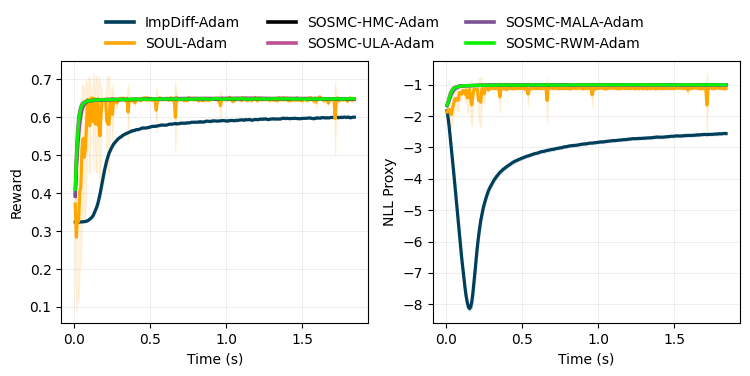

/var/folders/p7/j8d1ct3n6r5b879xs9vhfkfh0000gn/T/ipykernel_33701/3674886992.py:115: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(Y, axis=0)
/Users/jamiecuin/Documents/University/Imperial/StatML/SOSMC/Final Code/SOSMC/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


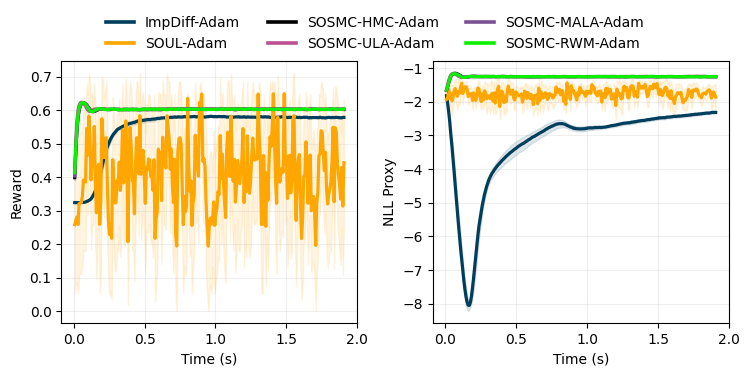

In [ ]:
dist_key = "dual_gaussian_sig1"
reward_key = "smooth_right"

loop_types = [
    "ImpDiff_Adam", 
    "SOUL_Adam",
    "SOSMC-HMC_Adam",
    "SOSMC-ULA_Adam", 
    "SOSMC-MALA_Adam", 
    "SOSMC-RWM_Adam",
]

seeds = list(range(10))
beta_kls = [0, 0.1]

run_settings = {
    "run_mode": "time",
    "max_time_seconds": 2.001,
    "max_steps": None,
    "utilise_warmup_step": True,
}

sweep_results = run_sweep(
    dist_key=dist_key,
    reward_key=reward_key,
    loop_types=loop_types,
    seeds=seeds,
    beta_kls=beta_kls,
    run_settings=run_settings,
    base_config=CONFIG_BASE,
    config_reward=CONFIG_REWARD,
    config_distribution=CONFIG_DISTRIBUTION,
    config_loop=CONFIG_LOOP,
    force_rerun=True,
    verbose=True,
)

for beta_kl in beta_kls:
    plot_reward_and_nll_fixed_beta(
        sweep_results,
        beta_kl=beta_kl,
        methods=loop_types,
        pdf_path=f"plots/V_dual_R_smooth_beta_{beta_kl}_Adam.pdf"
    )

## Experiment - $V_{dual}$ \& $R_{hard}$

[beta=0.001] [ImpDiff_Adam] [seed=0]
Running ImpDiff (JIT-step) for 2.0 seconds...
[beta=0.001] [ImpDiff_Adam] [seed=1]
Running ImpDiff (JIT-step) for 2.0 seconds...
[beta=0.001] [ImpDiff_Adam] [seed=2]
Running ImpDiff (JIT-step) for 2.0 seconds...
[beta=0.001] [ImpDiff_Adam] [seed=3]
Running ImpDiff (JIT-step) for 2.0 seconds...
[beta=0.001] [ImpDiff_Adam] [seed=4]
Running ImpDiff (JIT-step) for 2.0 seconds...
[beta=0.001] [ImpDiff_Adam] [seed=5]
Running ImpDiff (JIT-step) for 2.0 seconds...
[beta=0.001] [ImpDiff_Adam] [seed=6]
Running ImpDiff (JIT-step) for 2.0 seconds...
[beta=0.001] [ImpDiff_Adam] [seed=7]
Running ImpDiff (JIT-step) for 2.0 seconds...
[beta=0.001] [ImpDiff_Adam] [seed=8]
Running ImpDiff (JIT-step) for 2.0 seconds...
[beta=0.001] [ImpDiff_Adam] [seed=9]
Running ImpDiff (JIT-step) for 2.0 seconds...
[beta=0.001] [SOUL_Adam] [seed=0]
Running SOUL (JIT-step) for 2.0 seconds with N=10000, n_burn=5000, N_eff=5000...
[beta=0.001] [SOUL_Adam] [seed=1]
Running SOUL (JIT-ste

/var/folders/p7/j8d1ct3n6r5b879xs9vhfkfh0000gn/T/ipykernel_33701/3674886992.py:115: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(Y, axis=0)
/Users/jamiecuin/Documents/University/Imperial/StatML/SOSMC/Final Code/SOSMC/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


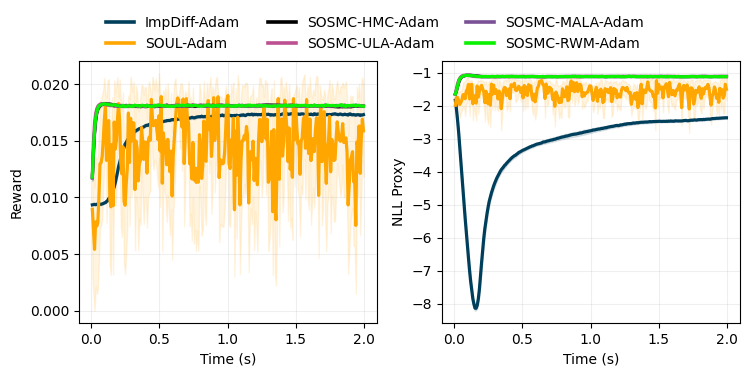

/var/folders/p7/j8d1ct3n6r5b879xs9vhfkfh0000gn/T/ipykernel_33701/3674886992.py:115: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(Y, axis=0)
/Users/jamiecuin/Documents/University/Imperial/StatML/SOSMC/Final Code/SOSMC/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


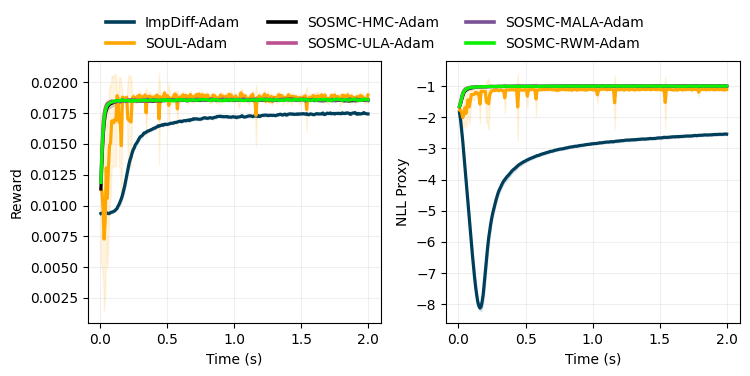

In [15]:
dist_key = "dual_gaussian_sig1"
reward_key = "hard_right"

loop_types = [
    "ImpDiff_Adam", 
    "SOUL_Adam",
    "SOSMC-HMC_Adam",
    "SOSMC-ULA_Adam", 
    "SOSMC-MALA_Adam", 
    "SOSMC-RWM_Adam",
]

seeds = list(range(10))
beta_kls = [0.001, 0]

run_settings = {
    "run_mode": "time",
    "max_time_seconds": 2.0,
    "max_steps": None,
    "utilise_warmup_step": True,
}

sweep_results = run_sweep(
    dist_key=dist_key,
    reward_key=reward_key,
    loop_types=loop_types,
    seeds=seeds,
    beta_kls=beta_kls,
    run_settings=run_settings,
    base_config=CONFIG_BASE,
    config_reward=CONFIG_REWARD,
    config_distribution=CONFIG_DISTRIBUTION,
    config_loop=CONFIG_LOOP,
    save_dir=None,
    force_rerun=True,
    verbose=True,
)

for beta_kl in beta_kls:
    plot_reward_and_nll_fixed_beta(
        sweep_results,
        beta_kl=beta_kl,
        methods=loop_types,
        pdf_path=f"plots/V_dual_R_hard_beta_{beta_kl}_Adam.pdf"
    )

## Experiment - $V_{sparse}$ \& $R_{hard}$

[beta=0.001] [ImpDiff_Adam] [seed=0]
Running ImpDiff (JIT-step) for 2.0 seconds...
[beta=0.001] [ImpDiff_Adam] [seed=1]
Running ImpDiff (JIT-step) for 2.0 seconds...
[beta=0.001] [ImpDiff_Adam] [seed=2]
Running ImpDiff (JIT-step) for 2.0 seconds...
[beta=0.001] [ImpDiff_Adam] [seed=3]
Running ImpDiff (JIT-step) for 2.0 seconds...
[beta=0.001] [ImpDiff_Adam] [seed=4]
Running ImpDiff (JIT-step) for 2.0 seconds...
[beta=0.001] [ImpDiff_Adam] [seed=5]
Running ImpDiff (JIT-step) for 2.0 seconds...
[beta=0.001] [ImpDiff_Adam] [seed=6]
Running ImpDiff (JIT-step) for 2.0 seconds...
[beta=0.001] [ImpDiff_Adam] [seed=7]
Running ImpDiff (JIT-step) for 2.0 seconds...
[beta=0.001] [ImpDiff_Adam] [seed=8]
Running ImpDiff (JIT-step) for 2.0 seconds...
[beta=0.001] [ImpDiff_Adam] [seed=9]
Running ImpDiff (JIT-step) for 2.0 seconds...
[beta=0.001] [SOUL_Adam] [seed=0]
Running SOUL (JIT-step) for 2.0 seconds with N=10000, n_burn=5000, N_eff=5000...
[beta=0.001] [SOUL_Adam] [seed=1]
Running SOUL (JIT-ste

/var/folders/p7/j8d1ct3n6r5b879xs9vhfkfh0000gn/T/ipykernel_33701/3674886992.py:115: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(Y, axis=0)
/Users/jamiecuin/Documents/University/Imperial/StatML/SOSMC/Final Code/SOSMC/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


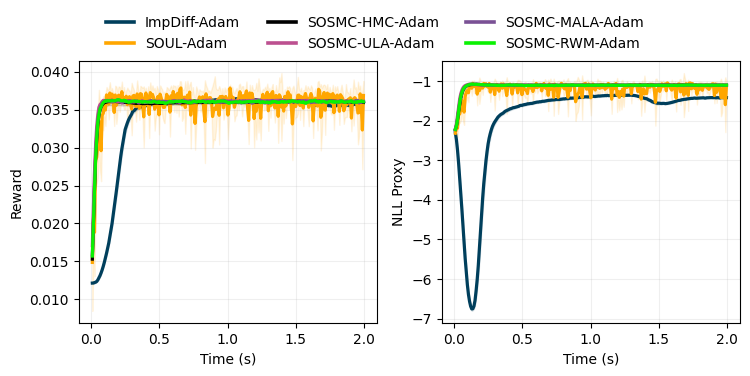

/var/folders/p7/j8d1ct3n6r5b879xs9vhfkfh0000gn/T/ipykernel_33701/3674886992.py:115: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(Y, axis=0)
/Users/jamiecuin/Documents/University/Imperial/StatML/SOSMC/Final Code/SOSMC/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


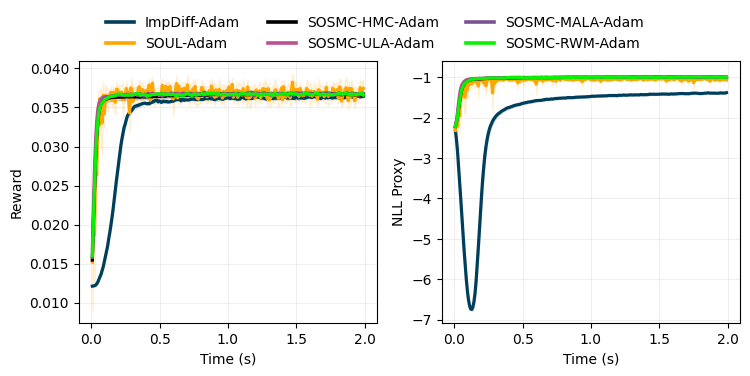

In [16]:
dist_key = "hex_sparse_sig2"
reward_key = "hard_right"

loop_types = [
    "ImpDiff_Adam", 
    "SOUL_Adam",
    "SOSMC-HMC_Adam",
    "SOSMC-ULA_Adam", 
    "SOSMC-MALA_Adam", 
    "SOSMC-RWM_Adam",
]

seeds = list(range(10))
beta_kls = [0.001, 0]

run_settings = {
    "run_mode": "time",
    "max_time_seconds": 2.0,
    "max_steps": None,
    "utilise_warmup_step": True,
}

sweep_results = run_sweep(
    dist_key=dist_key,
    reward_key=reward_key,
    loop_types=loop_types,
    seeds=seeds,
    beta_kls=beta_kls,
    run_settings=run_settings,
    base_config=CONFIG_BASE,
    config_reward=CONFIG_REWARD,
    config_distribution=CONFIG_DISTRIBUTION,
    config_loop=CONFIG_LOOP,
    save_dir=None,
    force_rerun=True,
    verbose=True,
)

for beta_kl in beta_kls:
    plot_reward_and_nll_fixed_beta(
        sweep_results,
        beta_kl=beta_kl,
        methods=loop_types,
        pdf_path=f"plots/V_sparse_R_hard_beta_{beta_kl}_Adam.pdf"
    )

## Experiment - $V_{tight}$ \& $R_{tight}$

[beta=0.1] [ImpDiff_Adam] [seed=0]
Running ImpDiff (JIT-step) for 2.0 seconds...
[beta=0.1] [ImpDiff_Adam] [seed=1]
Running ImpDiff (JIT-step) for 2.0 seconds...
[beta=0.1] [ImpDiff_Adam] [seed=2]
Running ImpDiff (JIT-step) for 2.0 seconds...
[beta=0.1] [ImpDiff_Adam] [seed=3]
Running ImpDiff (JIT-step) for 2.0 seconds...
[beta=0.1] [ImpDiff_Adam] [seed=4]
Running ImpDiff (JIT-step) for 2.0 seconds...
[beta=0.1] [ImpDiff_Adam] [seed=5]
Running ImpDiff (JIT-step) for 2.0 seconds...
[beta=0.1] [ImpDiff_Adam] [seed=6]
Running ImpDiff (JIT-step) for 2.0 seconds...
[beta=0.1] [ImpDiff_Adam] [seed=7]
Running ImpDiff (JIT-step) for 2.0 seconds...
[beta=0.1] [ImpDiff_Adam] [seed=8]
Running ImpDiff (JIT-step) for 2.0 seconds...
[beta=0.1] [ImpDiff_Adam] [seed=9]
Running ImpDiff (JIT-step) for 2.0 seconds...
[beta=0.1] [SOUL_Adam] [seed=0]
Running SOUL (JIT-step) for 2.0 seconds with N=10000, n_burn=5000, N_eff=5000...
[beta=0.1] [SOUL_Adam] [seed=1]
Running SOUL (JIT-step) for 2.0 seconds with 

/var/folders/p7/j8d1ct3n6r5b879xs9vhfkfh0000gn/T/ipykernel_33701/3674886992.py:115: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(Y, axis=0)
/Users/jamiecuin/Documents/University/Imperial/StatML/SOSMC/Final Code/SOSMC/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


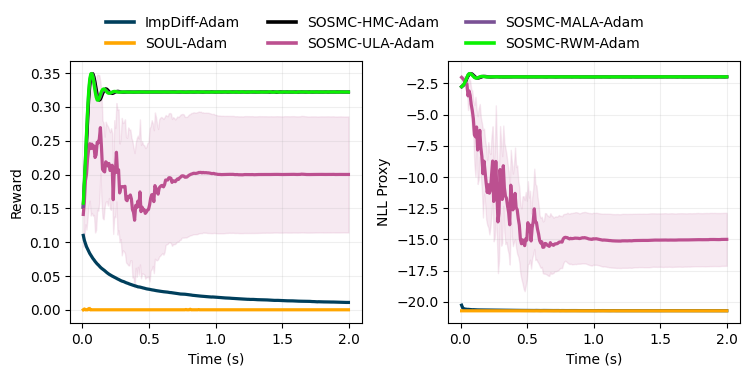

/var/folders/p7/j8d1ct3n6r5b879xs9vhfkfh0000gn/T/ipykernel_33701/3674886992.py:115: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(Y, axis=0)
/Users/jamiecuin/Documents/University/Imperial/StatML/SOSMC/Final Code/SOSMC/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


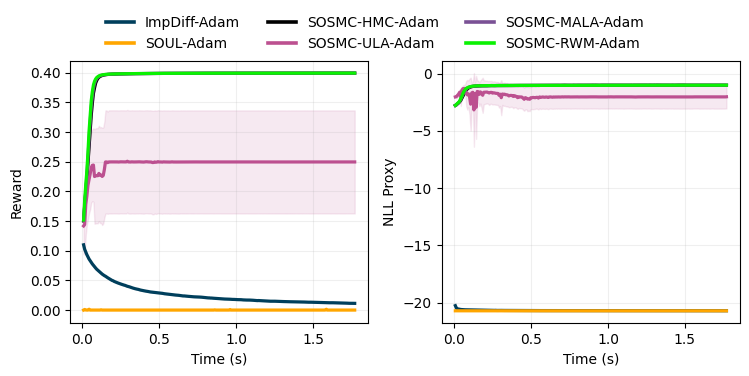

In [17]:
dist_key = "hex_tight_sig002"
reward_key = "hard_right_tight"

loop_types = [
    "ImpDiff_Adam", 
    "SOUL_Adam",
    "SOSMC-HMC_Adam",
    "SOSMC-ULA_Adam", 
    "SOSMC-MALA_Adam", 
    "SOSMC-RWM_Adam",
]

seeds = list(range(10))
beta_kls = [0.1, 0]

run_settings = {
    "run_mode": "time",
    "max_time_seconds": 2.0,
    "max_steps": None,
    "utilise_warmup_step": True,
}

sweep_results = run_sweep(
    dist_key=dist_key,
    reward_key=reward_key,
    loop_types=loop_types,
    seeds=seeds,
    beta_kls=beta_kls,
    run_settings=run_settings,
    base_config=CONFIG_BASE,
    config_reward=CONFIG_REWARD,
    config_distribution=CONFIG_DISTRIBUTION,
    config_loop=CONFIG_LOOP,
    save_dir=None,
    force_rerun=True,
    verbose=True,
)

for beta_kl in beta_kls:
    plot_reward_and_nll_fixed_beta(
        sweep_results,
        beta_kl=beta_kl,
        methods=loop_types,
        pdf_path=f"plots/V_tight_R_tight_beta_{beta_kl}_Adam.pdf"
    )

And now for $\mathrm{OPT} = \mathrm{SGD}$...

[beta=0] [ImpDiff_SGD] [seed=0]
Running ImpDiff (JIT-step) for 2.0 seconds...
[beta=0] [ImpDiff_SGD] [seed=1]
Running ImpDiff (JIT-step) for 2.0 seconds...
[beta=0] [ImpDiff_SGD] [seed=2]
Running ImpDiff (JIT-step) for 2.0 seconds...
[beta=0] [ImpDiff_SGD] [seed=3]
Running ImpDiff (JIT-step) for 2.0 seconds...
[beta=0] [ImpDiff_SGD] [seed=4]
Running ImpDiff (JIT-step) for 2.0 seconds...
[beta=0] [ImpDiff_SGD] [seed=5]
Running ImpDiff (JIT-step) for 2.0 seconds...
[beta=0] [ImpDiff_SGD] [seed=6]
Running ImpDiff (JIT-step) for 2.0 seconds...
[beta=0] [ImpDiff_SGD] [seed=7]
Running ImpDiff (JIT-step) for 2.0 seconds...
[beta=0] [ImpDiff_SGD] [seed=8]
Running ImpDiff (JIT-step) for 2.0 seconds...
[beta=0] [ImpDiff_SGD] [seed=9]
Running ImpDiff (JIT-step) for 2.0 seconds...
[beta=0] [SOUL_SGD] [seed=0]
Running SOUL (JIT-step) for 2.0 seconds with N=10000, n_burn=5000, N_eff=5000...
[beta=0] [SOUL_SGD] [seed=1]
Running SOUL (JIT-step) for 2.0 seconds with N=10000, n_burn=5000, N_eff=5000...


/var/folders/p7/j8d1ct3n6r5b879xs9vhfkfh0000gn/T/ipykernel_33701/3674886992.py:115: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(Y, axis=0)
/Users/jamiecuin/Documents/University/Imperial/StatML/SOSMC/Final Code/SOSMC/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


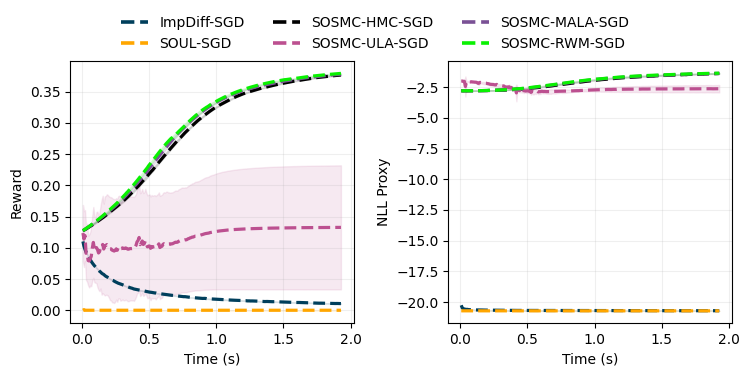

In [18]:
dist_key = "hex_tight_sig002"
reward_key = "hard_right_tight"

loop_types = [
    "ImpDiff_SGD", 
    "SOUL_SGD",
    "SOSMC-HMC_SGD",
    "SOSMC-ULA_SGD", 
    "SOSMC-MALA_SGD", 
    "SOSMC-RWM_SGD",
]

seeds = list(range(10))
beta_kls = [0]

run_settings = {
    "run_mode": "time",
    "max_time_seconds": 2.0,
    "max_steps": None,
    "utilise_warmup_step": True,
}

sweep_results = run_sweep(
    dist_key=dist_key,
    reward_key=reward_key,
    loop_types=loop_types,
    seeds=seeds,
    beta_kls=beta_kls,
    run_settings=run_settings,
    base_config=CONFIG_BASE,
    config_reward=CONFIG_REWARD,
    config_distribution=CONFIG_DISTRIBUTION,
    config_loop=CONFIG_LOOP,
    save_dir=None,
    force_rerun=True,
    verbose=True,
)

for beta_kl in beta_kls:
    plot_reward_and_nll_fixed_beta(
        sweep_results,
        beta_kl=beta_kl,
        methods=loop_types,
        pdf_path=f"plots/V_dual_R_hard_beta_{beta_kl}_SGD.pdf"
    )

## Problem Visualisation

In [19]:
def plot_reference_distributions(
    config_distribution,
    panel_specs,  # list of (dist_key, reward_key, panel_title)
    config_reward=None,
    xlim=(-6, 6),
    ylim=(-6, 6),
    grid_size=450,
    n_samples=1200,
    density_levels=18,
    reward_levels=6,
    cmap="viridis",
    reward_cmap="coolwarm",
    sample_alpha=0.04,
    sample_size=3,
    pdf_path=None,
    png_path=None,
    return_pdf_bytes=False,
):
    n_panels = len(panel_specs)
    if n_panels == 0:
        raise ValueError("panel_specs must be non-empty")

    plt.rcParams.update({
        "figure.dpi": 150,
        "savefig.dpi": 600,
        "font.size": 11,
        "axes.titlesize": 16,
        "axes.labelsize": 13,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "axes.linewidth": 1.2,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.02,
    })

    fig_width = 3.6 * n_panels + 0.8
    fig, axes = plt.subplots(
        1,
        n_panels,
        figsize=(fig_width, 3.9),
        sharex=True,
        sharey=True,
        constrained_layout=True,
    )
    if n_panels == 1:
        axes = [axes]

    xs = jnp.linspace(xlim[0], xlim[1], grid_size)
    ys = jnp.linspace(ylim[0], ylim[1], grid_size)
    XX, YY = jnp.meshgrid(xs, ys)
    XY = jnp.stack([XX.ravel(), YY.ravel()], axis=1)

    XX_np = np.asarray(XX)
    YY_np = np.asarray(YY)

    def eval_log_density(energy_func, theta, energy_params):
        energy_batch = jax.vmap(lambda x: energy_func(x, theta, **energy_params))
        E = energy_batch(XY).reshape(grid_size, grid_size)
        return np.asarray(-E)

    def eval_reward(reward_func, reward_params):
        reward_batch = jax.vmap(lambda x: reward_func(x, **reward_params))
        R = reward_batch(XY).reshape(grid_size, grid_size)
        return np.asarray(R)

    
    # Precompute density fields...
    log_densities = []
    dist_cfgs = []

    for dist_key, _, _ in panel_specs:
        cfg = config_distribution[dist_key]
        dist_cfgs.append(cfg)
        log_densities.append(
            eval_log_density(
                cfg["energy_func"],
                cfg["sampler_params"]["sampling_theta"],
                cfg["energy_params"],
            )
        )

    stacked_density = np.stack([d.ravel() for d in log_densities])
    density_levels_shared = np.quantile(
        stacked_density, np.linspace(0.72, 0.995, density_levels)
    )

    # Precompute reward fields...
    reward_fields = []
    reward_cfgs = []

    for _, reward_key, _ in panel_specs:
        if reward_key is None:
            reward_cfgs.append(None)
            reward_fields.append(None)
        else:
            if config_reward is None:
                raise ValueError(
                    "config_reward must be provided when reward overlays are used"
                )
            rcfg = config_reward[reward_key]
            reward_cfgs.append(rcfg)
            reward_fields.append(
                eval_reward(rcfg["reward_func"], rcfg["params"])
            )

    # Share reward contour levels only for smooth rewards
    smooth_rewards = []
    for (_, reward_key, _), reward_field in zip(panel_specs, reward_fields):
        if reward_key is not None and reward_key != "hard_right":
            smooth_rewards.append(reward_field)

    if smooth_rewards:
        stacked_reward = np.stack([r.ravel() for r in smooth_rewards])
        reward_levels_shared = np.quantile(
            stacked_reward, np.linspace(0.70, 0.995, reward_levels)
        )
        reward_norm = colors.Normalize(
            vmin=float(np.min(reward_levels_shared)),
            vmax=float(np.max(reward_levels_shared)),
        )
    else:
        reward_levels_shared = None
        reward_norm = None

    cf = None

    for col, ((dist_key, reward_key, panel_title), cfg, log_density, reward_field) in enumerate(
        zip(panel_specs, dist_cfgs, log_densities, reward_fields)
    ):
        ax = axes[col]

        sampler_func = cfg["sampler_func"]
        theta_ref = cfg["sampler_params"]["sampling_theta"]
        sig_sq = cfg["sampler_params"]["sig_sq"]
        means = cfg["sampler_params"]["means"]

        # Base density as filled contours
        cf = ax.contourf(
            XX_np,
            YY_np,
            log_density,
            levels=density_levels_shared,
            cmap=cmap,
            extend="both",
        )
        ax.contour(
            XX_np,
            YY_np,
            log_density,
            levels=density_levels_shared,
            colors="k",
            linewidths=0.35,
            alpha=0.18,
        )

        # Reward overlay
        if reward_field is not None:
            if reward_key == "hard_right":
                # Explicitly show discontinuity/support boundary!
                mask = (reward_field > 0).astype(float)

                ax.contour(
                    XX_np,
                    YY_np,
                    mask,
                    levels=[0.5],
                    colors=["black"],
                    linestyles=":",
                    linewidths=1.6,
                    zorder=5,
                )

                pos = reward_field.copy()
                pos[pos <= 0] = np.nan
                finite_pos = pos[np.isfinite(pos)]
                if finite_pos.size > 0:
                    local_levels = np.quantile(finite_pos, [0.70, 0.85, 0.95])
                    ax.contour(
                        XX_np,
                        YY_np,
                        pos,
                        levels=local_levels,
                        cmap=reward_cmap,
                        norm=reward_norm,
                        linewidths=1.0,
                        alpha=0.95,
                        zorder=5,
                    )

            else:
                if reward_levels_shared is not None:
                    ax.contour(
                        XX_np,
                        YY_np,
                        reward_field,
                        levels=reward_levels_shared,
                        cmap=reward_cmap,
                        norm=reward_norm,
                        linewidths=1.4,
                        alpha=0.98,
                        zorder=5,
                    )

        # Get samples
        sampler_ref = partial(
            sampler_func,
            sig_sq=sig_sq,
            means=means,
            sampling_theta=theta_ref,
        )
        rng = jax.random.PRNGKey(200 + col)
        samples_ref = np.asarray(sampler_ref(rng, jnp.zeros((n_samples, 2))))

        ax.scatter(
            samples_ref[:, 0],
            samples_ref[:, 1],
            s=sample_size,
            alpha=sample_alpha,
            c="#2bb3c0",
            edgecolors="none",
            rasterized=True,
            zorder=3,
        )

        ax.set_title(panel_title)
        ax.set_xlim(*xlim)
        ax.set_ylim(*ylim)
        ax.set_aspect("equal", adjustable="box")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.tick_params(direction="out", length=4, width=1.1)
        ax.grid(False)

    ticks = np.arange(np.ceil(xlim[0] / 2) * 2, np.floor(xlim[1] / 2) * 2 + 0.1, 2)
    for ax in axes:
        ax.set_xticks(ticks)
        ax.set_yticks(ticks)
        ax.set_xlabel(r"$x_1$")

    axes[0].set_ylabel(r"$x_2$")

    # Reward colorbar -> only if smooth rewards are present
    if reward_levels_shared is not None:
        sm = cm.ScalarMappable(norm=reward_norm, cmap=reward_cmap)
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=axes, location="right", fraction=0.03, pad=0.02)
        cbar.set_label("Reward Level")

    if pdf_path is not None:
        fig.savefig(pdf_path, format="pdf")

    if png_path is not None:
        fig.savefig(png_path, format="png", dpi=600)

    if return_pdf_bytes:
        buf = BytesIO()
        fig.savefig(buf, format="pdf")
        buf.seek(0)
        return buf.getvalue()

    return fig

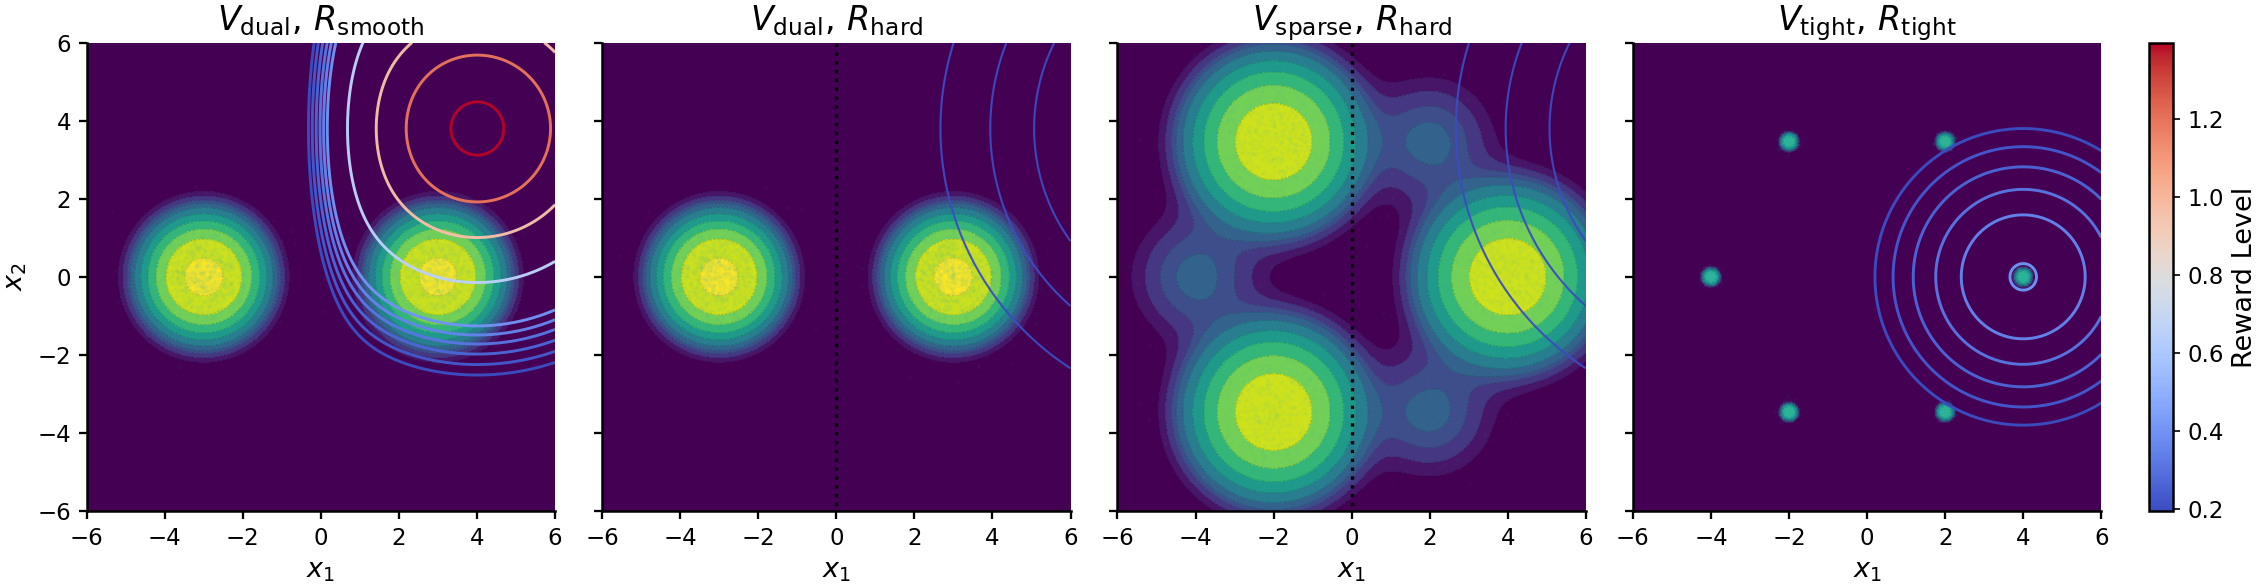

In [20]:
panel_specs = [
    ("dual_gaussian_sig1", "smooth_right", r"$V_{\mathrm{dual}},\, R_{\mathrm{smooth}}$"),
    ("dual_gaussian_sig1", "hard_right", r"$V_{\mathrm{dual}},\, R_{\mathrm{hard}}$"),
    ("hex_sparse_sig2", "hard_right", r"$V_{\mathrm{sparse}},\, R_{\mathrm{hard}}$"),
    ("hex_tight_sig002", "hard_right_tight", r"$V_{\mathrm{tight}},\, R_{\mathrm{tight}}$"),
]

fig = plot_reference_distributions(
    CONFIG_DISTRIBUTION,
    panel_specs,
    config_reward=CONFIG_REWARD,
    xlim=(-6, 6),
    ylim=(-6, 6),
    density_levels=10,
    reward_levels=10,
    grid_size=280,
    n_samples=3000,
    pdf_path="plots/reference_distributions_with_rewards.pdf",
)
plt.show()